# Nöro-Eğitimde Veri Analizi: EEG Dalga Boyları ile Öğrenme Süreçlerinin Optimizasyonu

### Haluk Bayatlı - 23100011030

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import style
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import RobustScaler,OneHotEncoder
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split,GridSearchCV,cross_validate
from sklearn.metrics import accuracy_score, f1_score, precision_score,recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib
from scipy.stats import shapiro, pearsonr, spearmanr, f_oneway, kruskal, friedmanchisquare, wilcoxon, stats, chi2_contingency, mannwhitneyu
import math
import warnings
warnings.filterwarnings("ignore")

# 1. Veri Seti

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
demographic_data = pd.read_csv("demographic_info.csv")
demographic_data.columns = demographic_data.columns.str.strip()
demographic_data.rename(columns={"subject ID":"SubjectID","age":"Age","ethnicity":"Ethnicity","gender":"Gender"},inplace=True)
demographic_data

,SubjectID,Age,Ethnicity,Gender
0,0,25,Han Chinese,M
1,1,24,Han Chinese,M
2,2,31,English,M
3,3,28,Han Chinese,F
4,4,24,Bengali,M
5,5,24,Han Chinese,M
6,6,24,Han Chinese,M
7,7,25,Han Chinese,M
8,8,25,Han Chinese,M
9,9,24,Han Chinese,F


In [4]:
# EEG Sinyal Verileri
eeg_data = pd.read_csv("EEG_data.csv")
eeg_data

,SubjectID,VideoID,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,predefinedlabel,user-definedlabeln
0,0.0,0.0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0,0.0
1,0.0,0.0,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0,0.0
2,0.0,0.0,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0,0.0
3,0.0,0.0,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0,0.0
4,0.0,0.0,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12806,9.0,9.0,64.0,38.0,-39.0,127574.0,9951.0,709.0,21732.0,3872.0,39728.0,2598.0,960.0,1.0,0.0
12807,9.0,9.0,61.0,35.0,-275.0,323061.0,797464.0,153171.0,145805.0,39829.0,571280.0,36574.0,10010.0,1.0,0.0
12808,9.0,9.0,60.0,29.0,-426.0,680989.0,154296.0,40068.0,39122.0,10966.0,26975.0,20427.0,2024.0,1.0,0.0
12809,9.0,9.0,60.0,29.0,-84.0,366269.0,27346.0,11444.0,9932.0,1939.0,3283.0,12323.0,1764.0,1.0,0.0


In [5]:
# İki Veri Seti Birleştirme
new_eeg_data = pd.merge(eeg_data,demographic_data,how="inner",on="SubjectID")
new_eeg_data

,SubjectID,VideoID,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,predefinedlabel,user-definedlabeln,Age,Ethnicity,Gender
0,0.0,0.0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0,0.0,25,Han Chinese,M
1,0.0,0.0,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0,0.0,25,Han Chinese,M
2,0.0,0.0,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0,0.0,25,Han Chinese,M
3,0.0,0.0,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0,0.0,25,Han Chinese,M
4,0.0,0.0,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0,0.0,25,Han Chinese,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12806,9.0,9.0,64.0,38.0,-39.0,127574.0,9951.0,709.0,21732.0,3872.0,39728.0,2598.0,960.0,1.0,0.0,24,Han Chinese,F
12807,9.0,9.0,61.0,35.0,-275.0,323061.0,797464.0,153171.0,145805.0,39829.0,571280.0,36574.0,10010.0,1.0,0.0,24,Han Chinese,F
12808,9.0,9.0,60.0,29.0,-426.0,680989.0,154296.0,40068.0,39122.0,10966.0,26975.0,20427.0,2024.0,1.0,0.0,24,Han Chinese,F
12809,9.0,9.0,60.0,29.0,-84.0,366269.0,27346.0,11444.0,9932.0,1939.0,3283.0,12323.0,1764.0,1.0,0.0,24,Han Chinese,F


In [6]:
cols = new_eeg_data.columns.to_list()
left_cols = ["SubjectID","Gender","Age","Ethnicity","VideoID"]
new_order = left_cols + [c for c in cols if c not in left_cols]
new_eeg_data = new_eeg_data[new_order]
new_eeg_data.columns = [new_col_name.capitalize() for new_col_name in new_order]
new_column_names = {
    'Subjectid': 'SubjectID',
    'Videoid': 'VideoID',
    'Predefinedlabel': 'PredefinedLabel',
    'User-definedlabeln': 'UserDefinedLabel'
}
new_eeg_data.rename(columns=new_column_names, inplace=True)
print("New columns names:")
print(new_eeg_data.columns)
new_eeg_data

New columns names:
Index(['SubjectID', 'Gender', 'Age', 'Ethnicity', 'VideoID', 'Attention',
       'Mediation', 'Raw', 'Delta', 'Theta', 'Alpha1', 'Alpha2', 'Beta1',
       'Beta2', 'Gamma1', 'Gamma2', 'PredefinedLabel', 'UserDefinedLabel'],
      dtype='object')


,SubjectID,Gender,Age,Ethnicity,VideoID,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,PredefinedLabel,UserDefinedLabel
0,0.0,M,25,Han Chinese,0.0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0,0.0
1,0.0,M,25,Han Chinese,0.0,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0,0.0
2,0.0,M,25,Han Chinese,0.0,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0,0.0
3,0.0,M,25,Han Chinese,0.0,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0,0.0
4,0.0,M,25,Han Chinese,0.0,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12806,9.0,F,24,Han Chinese,9.0,64.0,38.0,-39.0,127574.0,9951.0,709.0,21732.0,3872.0,39728.0,2598.0,960.0,1.0,0.0
12807,9.0,F,24,Han Chinese,9.0,61.0,35.0,-275.0,323061.0,797464.0,153171.0,145805.0,39829.0,571280.0,36574.0,10010.0,1.0,0.0
12808,9.0,F,24,Han Chinese,9.0,60.0,29.0,-426.0,680989.0,154296.0,40068.0,39122.0,10966.0,26975.0,20427.0,2024.0,1.0,0.0
12809,9.0,F,24,Han Chinese,9.0,60.0,29.0,-84.0,366269.0,27346.0,11444.0,9932.0,1939.0,3283.0,12323.0,1764.0,1.0,0.0


In [7]:
new_eeg_data.head(100)

,SubjectID,Gender,Age,Ethnicity,VideoID,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,PredefinedLabel,UserDefinedLabel
0,0.0,M,25,Han Chinese,0.0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0,0.0
1,0.0,M,25,Han Chinese,0.0,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0,0.0
2,0.0,M,25,Han Chinese,0.0,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0,0.0
3,0.0,M,25,Han Chinese,0.0,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0,0.0
4,0.0,M,25,Han Chinese,0.0,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,M,25,Han Chinese,0.0,87.0,57.0,49.0,5655.0,3495.0,8717.0,13995.0,12292.0,23727.0,18075.0,12990.0,0.0,0.0
96,0.0,M,25,Han Chinese,0.0,70.0,53.0,42.0,453092.0,42420.0,4002.0,1224.0,2331.0,5716.0,8466.0,1175.0,0.0,0.0
97,0.0,M,25,Han Chinese,0.0,67.0,57.0,12.0,7071.0,13836.0,6204.0,8102.0,5014.0,30012.0,67918.0,16944.0,0.0,0.0
98,0.0,M,25,Han Chinese,0.0,66.0,60.0,101.0,189432.0,93096.0,56068.0,13748.0,18651.0,31468.0,39327.0,14499.0,0.0,0.0


In [8]:
new_eeg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12811 entries, 0 to 12810
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SubjectID         12811 non-null  float64
 1   Gender            12811 non-null  object 
 2   Age               12811 non-null  int64  
 3   Ethnicity         12811 non-null  object 
 4   VideoID           12811 non-null  float64
 5   Attention         12811 non-null  float64
 6   Mediation         12811 non-null  float64
 7   Raw               12811 non-null  float64
 8   Delta             12811 non-null  float64
 9   Theta             12811 non-null  float64
 10  Alpha1            12811 non-null  float64
 11  Alpha2            12811 non-null  float64
 12  Beta1             12811 non-null  float64
 13  Beta2             12811 non-null  float64
 14  Gamma1            12811 non-null  float64
 15  Gamma2            12811 non-null  float64
 16  PredefinedLabel   12811 non-null  float6

In [9]:
new_eeg_data["SubjectID"] = new_eeg_data["SubjectID"].astype(int)
new_eeg_data["VideoID"] = new_eeg_data["VideoID"].astype(int)
new_eeg_data["Ethnicity"] = pd.Categorical(new_eeg_data["Ethnicity"])
new_eeg_data["Gender"] = pd.Categorical(new_eeg_data["Gender"])
new_eeg_data.info()
new_eeg_data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12811 entries, 0 to 12810
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SubjectID         12811 non-null  int64   
 1   Gender            12811 non-null  category
 2   Age               12811 non-null  int64   
 3   Ethnicity         12811 non-null  category
 4   VideoID           12811 non-null  int64   
 5   Attention         12811 non-null  float64 
 6   Mediation         12811 non-null  float64 
 7   Raw               12811 non-null  float64 
 8   Delta             12811 non-null  float64 
 9   Theta             12811 non-null  float64 
 10  Alpha1            12811 non-null  float64 
 11  Alpha2            12811 non-null  float64 
 12  Beta1             12811 non-null  float64 
 13  Beta2             12811 non-null  float64 
 14  Gamma1            12811 non-null  float64 
 15  Gamma2            12811 non-null  float64 
 16  PredefinedLabel   1281

,SubjectID,Gender,Age,Ethnicity,VideoID,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,PredefinedLabel,UserDefinedLabel
0,0,M,25,Han Chinese,0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0,0.0
1,0,M,25,Han Chinese,0,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0,0.0
2,0,M,25,Han Chinese,0,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0,0.0
3,0,M,25,Han Chinese,0,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0,0.0
4,0,M,25,Han Chinese,0,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12806,9,F,24,Han Chinese,9,64.0,38.0,-39.0,127574.0,9951.0,709.0,21732.0,3872.0,39728.0,2598.0,960.0,1.0,0.0
12807,9,F,24,Han Chinese,9,61.0,35.0,-275.0,323061.0,797464.0,153171.0,145805.0,39829.0,571280.0,36574.0,10010.0,1.0,0.0
12808,9,F,24,Han Chinese,9,60.0,29.0,-426.0,680989.0,154296.0,40068.0,39122.0,10966.0,26975.0,20427.0,2024.0,1.0,0.0
12809,9,F,24,Han Chinese,9,60.0,29.0,-84.0,366269.0,27346.0,11444.0,9932.0,1939.0,3283.0,12323.0,1764.0,1.0,0.0


In [10]:
new_eeg_data.nunique().reset_index().rename(columns={"index": "Column", 0: "Unique Count"})

,Column,Unique Count
0,SubjectID,10
1,Gender,2
2,Age,4
3,Ethnicity,3
4,VideoID,10
5,Attention,61
6,Mediation,61
7,Raw,1104
8,Delta,12280
9,Theta,12070


# 2. Eksik Veri

<Axes: >

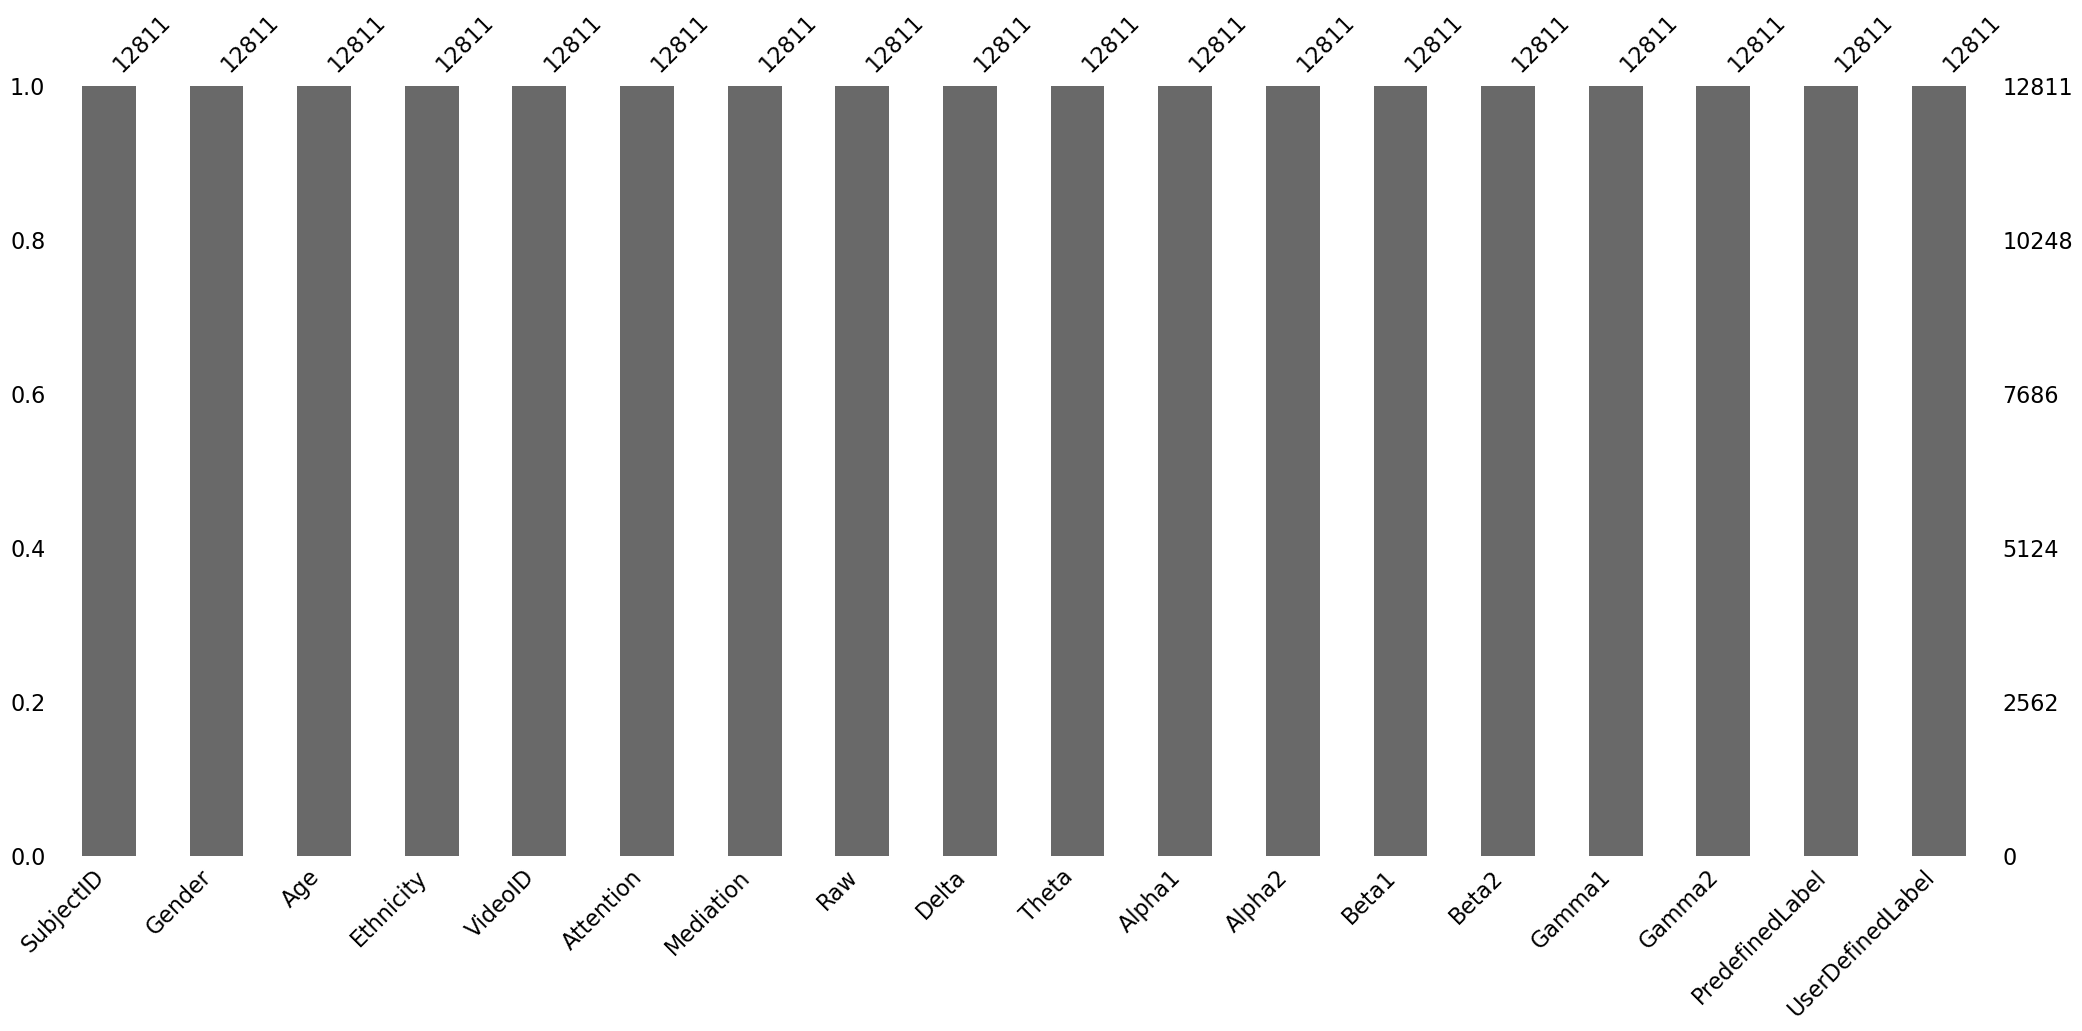

In [11]:
msno.bar(new_eeg_data)

<Axes: >

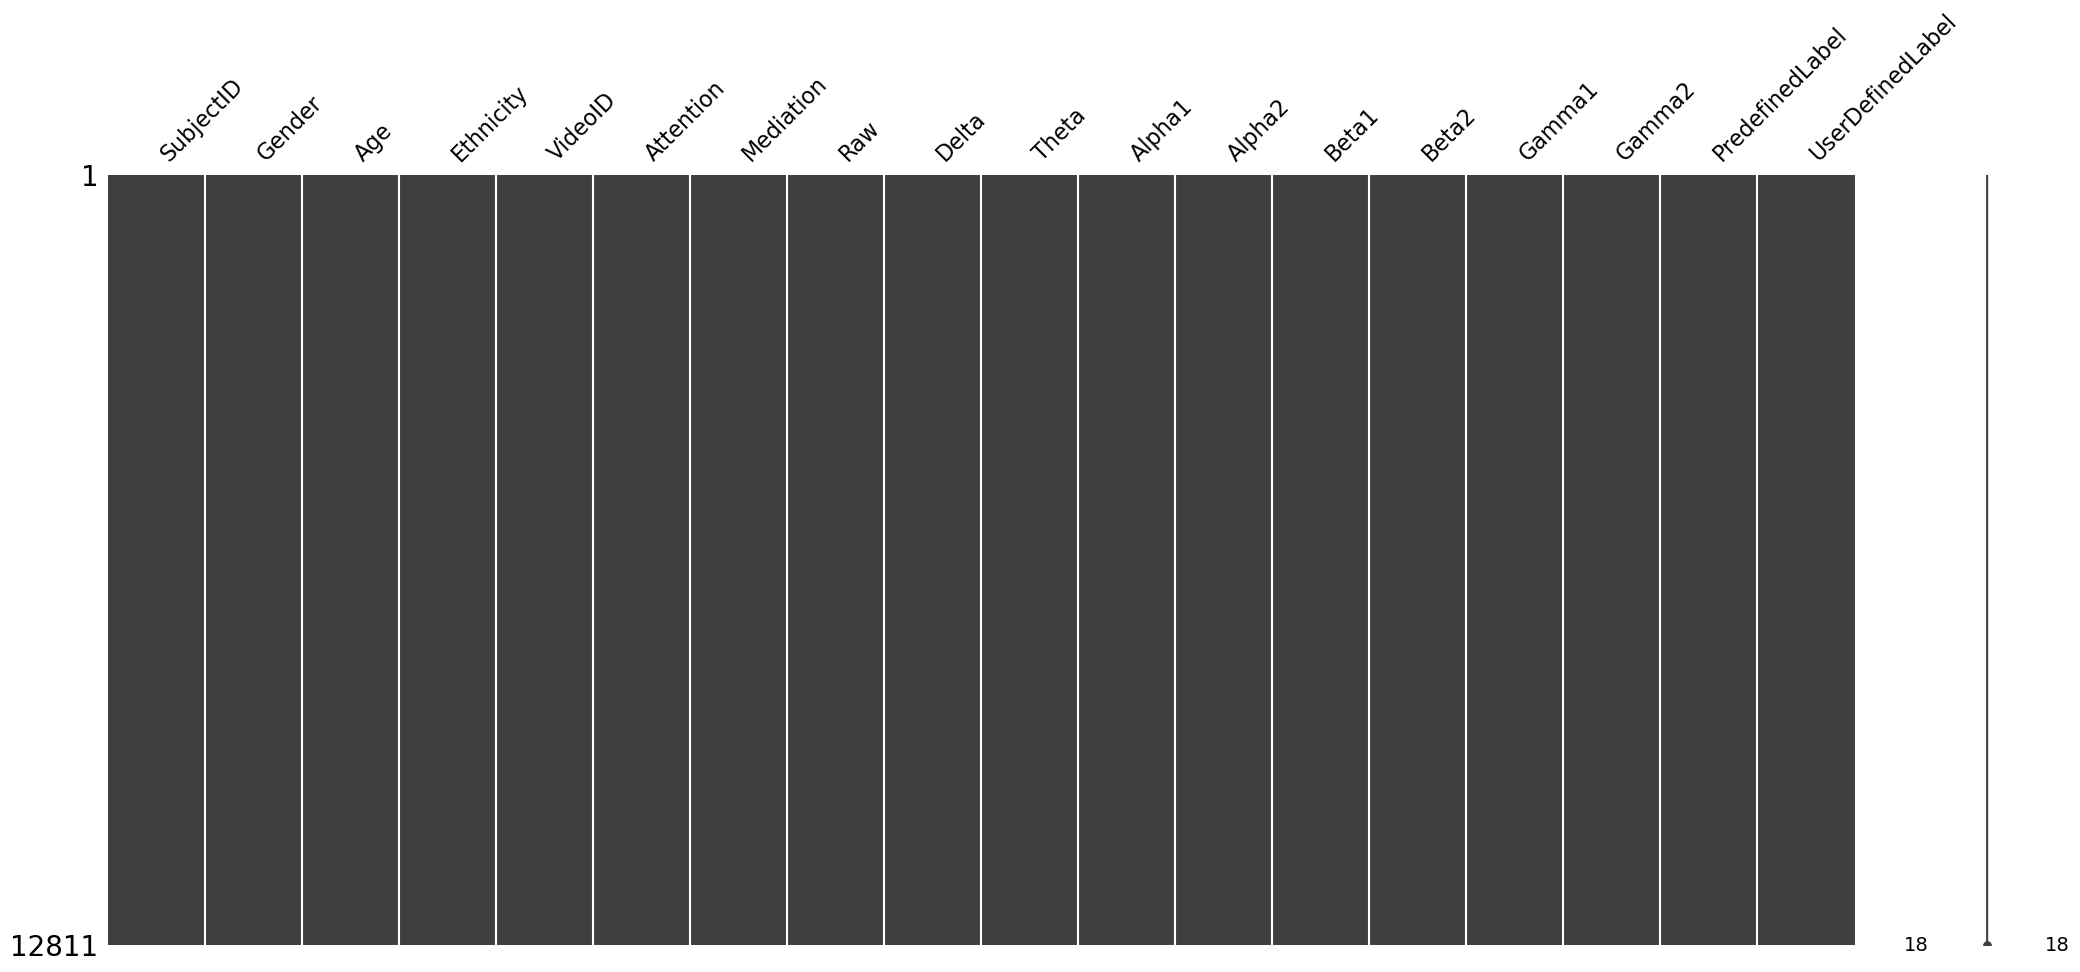

In [12]:
msno.matrix(new_eeg_data)

<Axes: >

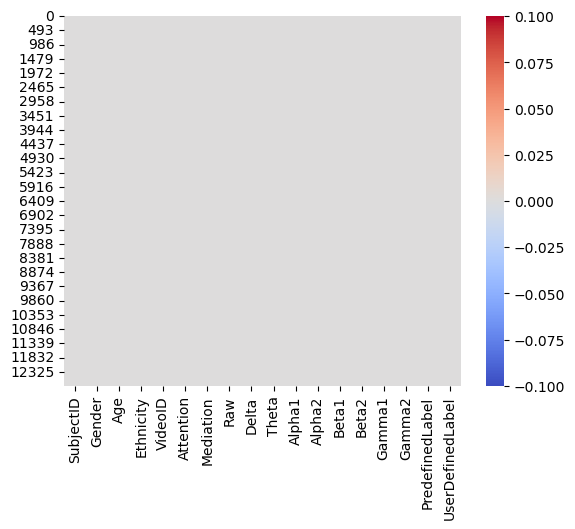

In [13]:
sns.heatmap(new_eeg_data.isnull(),cbar=True,cmap="coolwarm")

# 3. Veri Dağılımları

In [14]:
ethnicity_ohe = OneHotEncoder(sparse_output=False)
gender_ohe = OneHotEncoder(sparse_output=False)
videoid_ohe = OneHotEncoder(sparse_output=False)

def ohe_inplace(df, col, encoder):
    encoded = pd.DataFrame(
        encoder.fit_transform(df[[col]]),
        columns=encoder.get_feature_names_out([col]),
        index=df.index
    )
    col_idx = df.columns.get_loc(col)
    df = df.drop(columns=[col])
    for i, new_col in enumerate(encoded.columns):
        df.insert(col_idx + i, new_col, encoded[new_col])
    return df

new_eeg_data = ohe_inplace(new_eeg_data, "Ethnicity", ethnicity_ohe)
new_eeg_data = ohe_inplace(new_eeg_data, "Gender", gender_ohe)
new_eeg_data = ohe_inplace(new_eeg_data, "VideoID", videoid_ohe)

In [15]:
new_eeg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12811 entries, 0 to 12810
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SubjectID              12811 non-null  int64  
 1   Gender_F               12811 non-null  float64
 2   Gender_M               12811 non-null  float64
 3   Age                    12811 non-null  int64  
 4   Ethnicity_Bengali      12811 non-null  float64
 5   Ethnicity_English      12811 non-null  float64
 6   Ethnicity_Han Chinese  12811 non-null  float64
 7   VideoID_0              12811 non-null  float64
 8   VideoID_1              12811 non-null  float64
 9   VideoID_2              12811 non-null  float64
 10  VideoID_3              12811 non-null  float64
 11  VideoID_4              12811 non-null  float64
 12  VideoID_5              12811 non-null  float64
 13  VideoID_6              12811 non-null  float64
 14  VideoID_7              12811 non-null  float64
 15  Vi

## 3.1 Özelliklerin Dağılımı

In [16]:
sns.set_style("whitegrid")

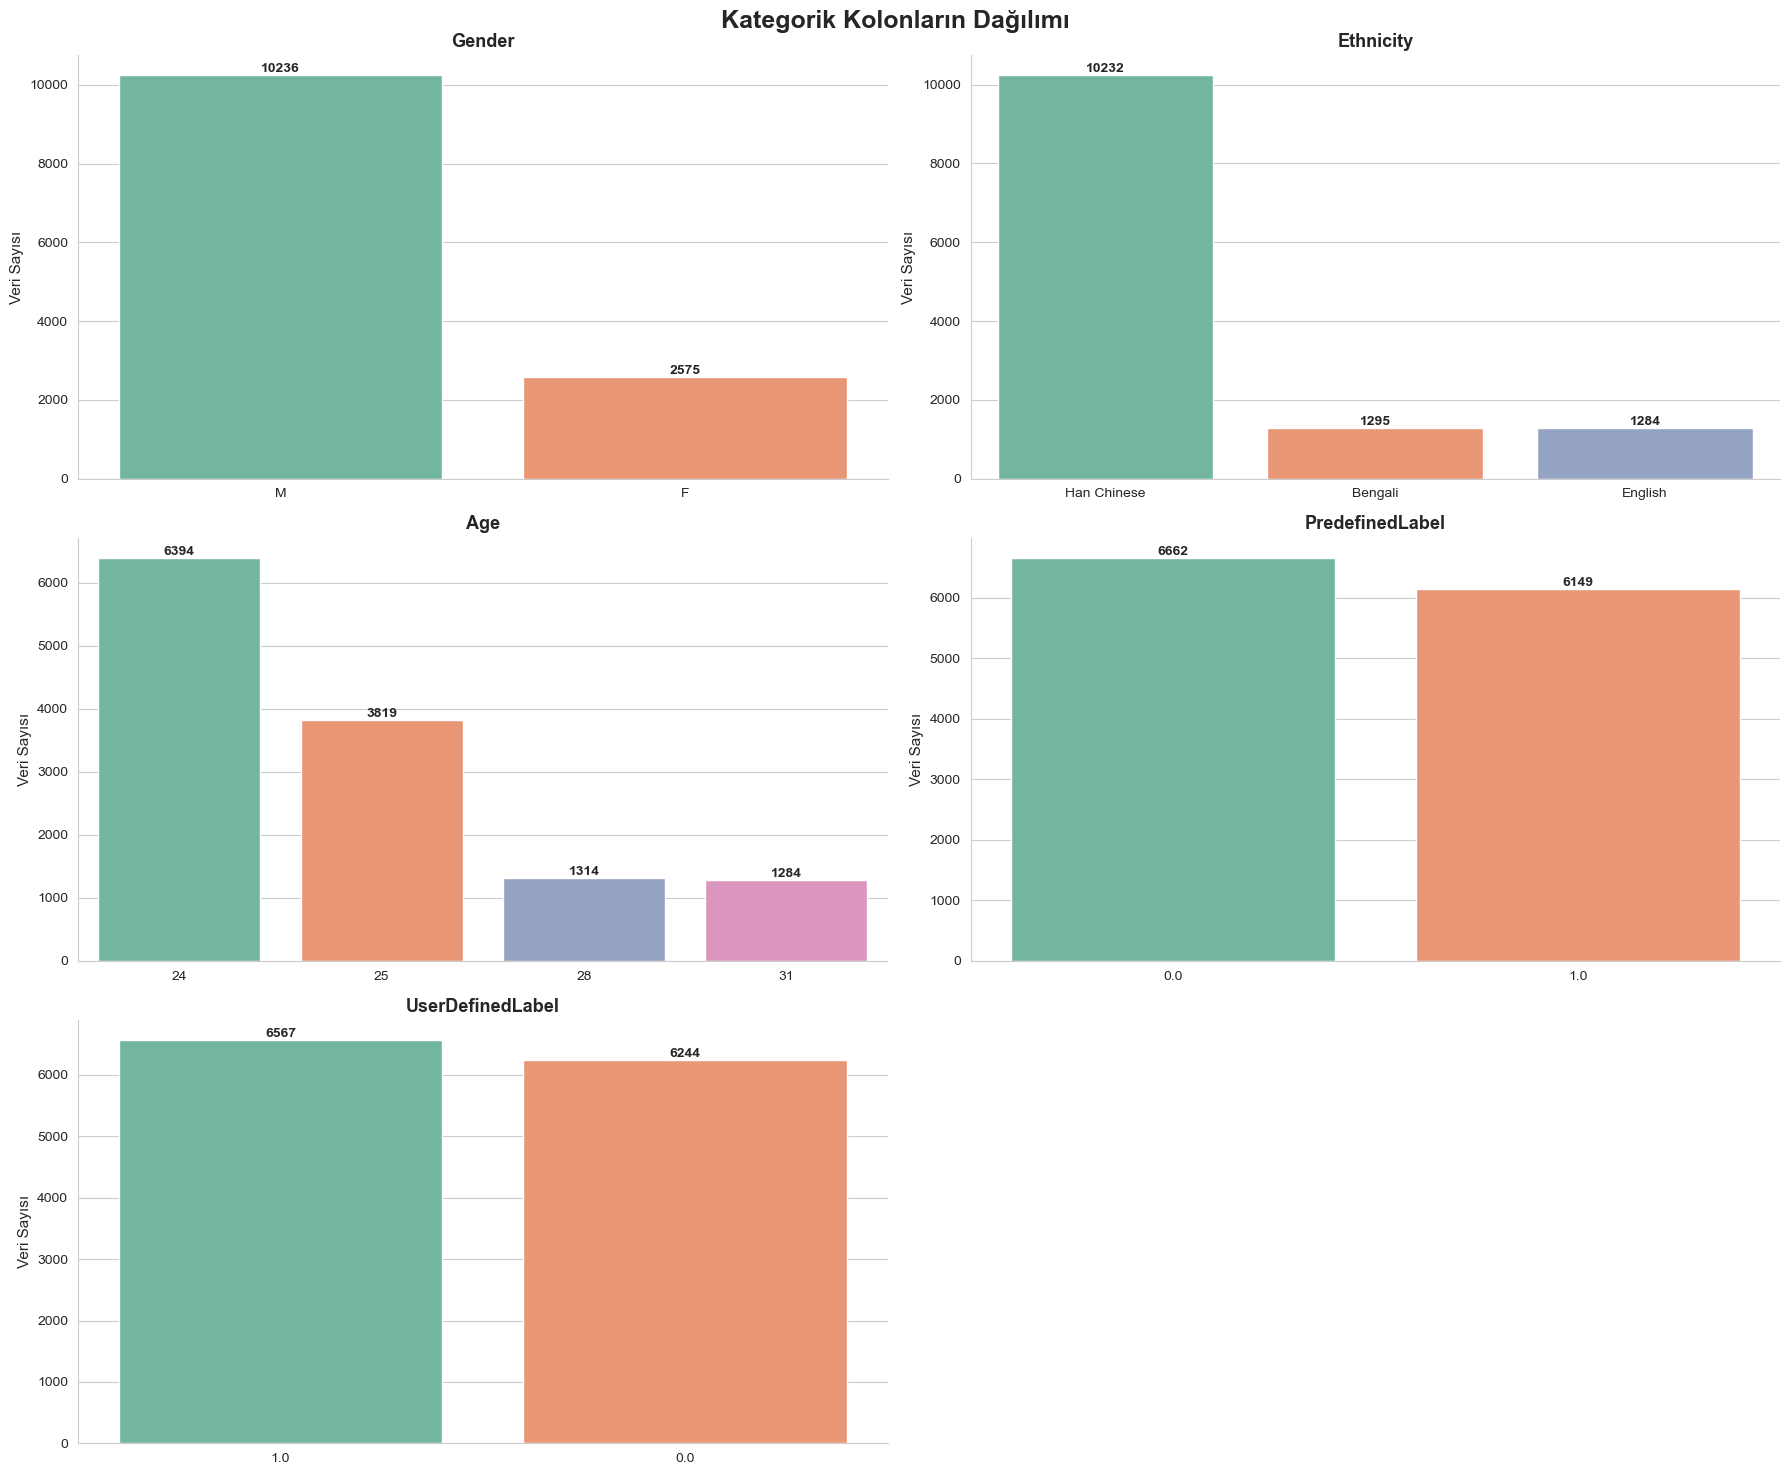

In [17]:
gender_cols = [c for c in new_eeg_data.columns if c.startswith("Gender_")]
ethnicity_cols = [c for c in new_eeg_data.columns if c.startswith("Ethnicity_")]

_gender_series = new_eeg_data[gender_cols].idxmax(axis=1).str.replace("Gender_", "")
_ethnicity_series = new_eeg_data[ethnicity_cols].idxmax(axis=1).str.replace("Ethnicity_", "")

plot_df = new_eeg_data.copy()
plot_df["Gender"] = _gender_series
plot_df["Ethnicity"] = _ethnicity_series

categorical_cols = ["Gender", "Ethnicity", "Age", "PredefinedLabel", "UserDefinedLabel"]
categorical_cols = [c for c in categorical_cols if c in plot_df.columns]

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()
fig.suptitle("Kategorik Kolonların Dağılımı", fontsize=18, fontweight="bold")

for i, col in enumerate(categorical_cols):
    order = plot_df[col].value_counts().index
    sns.countplot(data=plot_df, x=col, order=order, palette="Set2", ax=axes[i])
    axes[i].set_title(f"{col}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Veri Sayısı", fontsize=11)
    axes[i].tick_params(axis="x")
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())}",
                         (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha="center", va="bottom", fontsize=10, fontweight="bold")

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])
sns.despine()
plt.tight_layout()
plt.show()

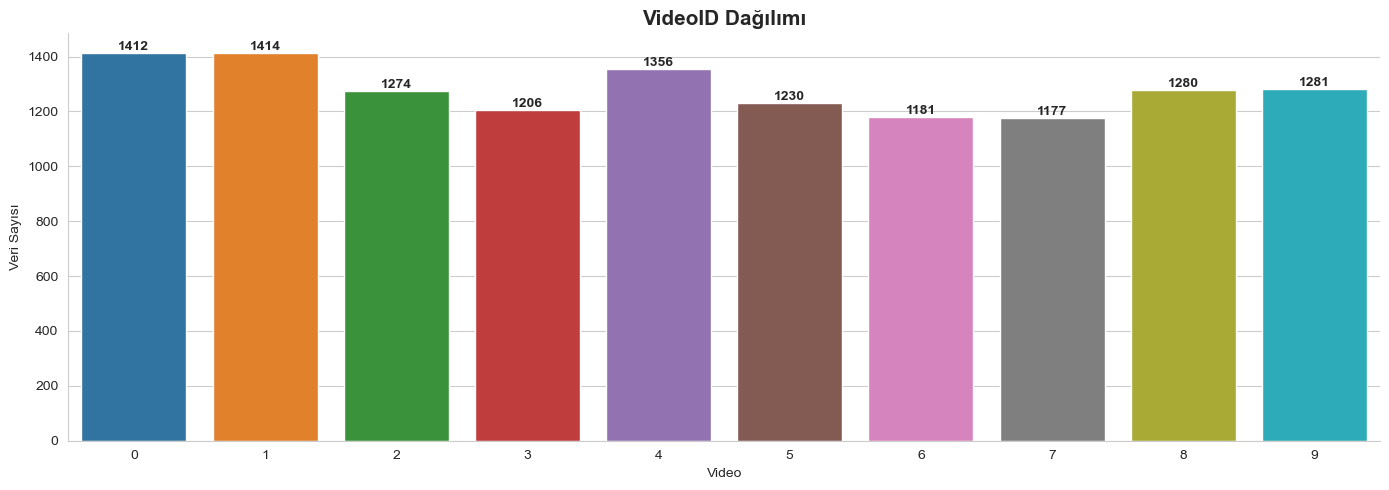

In [18]:
video_series = new_eeg_data[[c for c in new_eeg_data.columns if c.startswith("VideoID_")]]\
    .idxmax(axis=1)\
    .str.replace("VideoID_", "")\
    .astype(int)

video_df = video_series.value_counts().sort_index().reset_index()
video_df.columns = ["VideoID", "Veri Sayısı"]

palette = sns.color_palette("tab10", len(video_df))

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=video_df, x="VideoID", y="Veri Sayısı", palette=palette, ax=ax)
ax.set_title("VideoID Dağılımı", fontsize=15, fontweight="bold")
ax.set_xlabel("Video")
ax.set_ylabel("Veri Sayısı")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

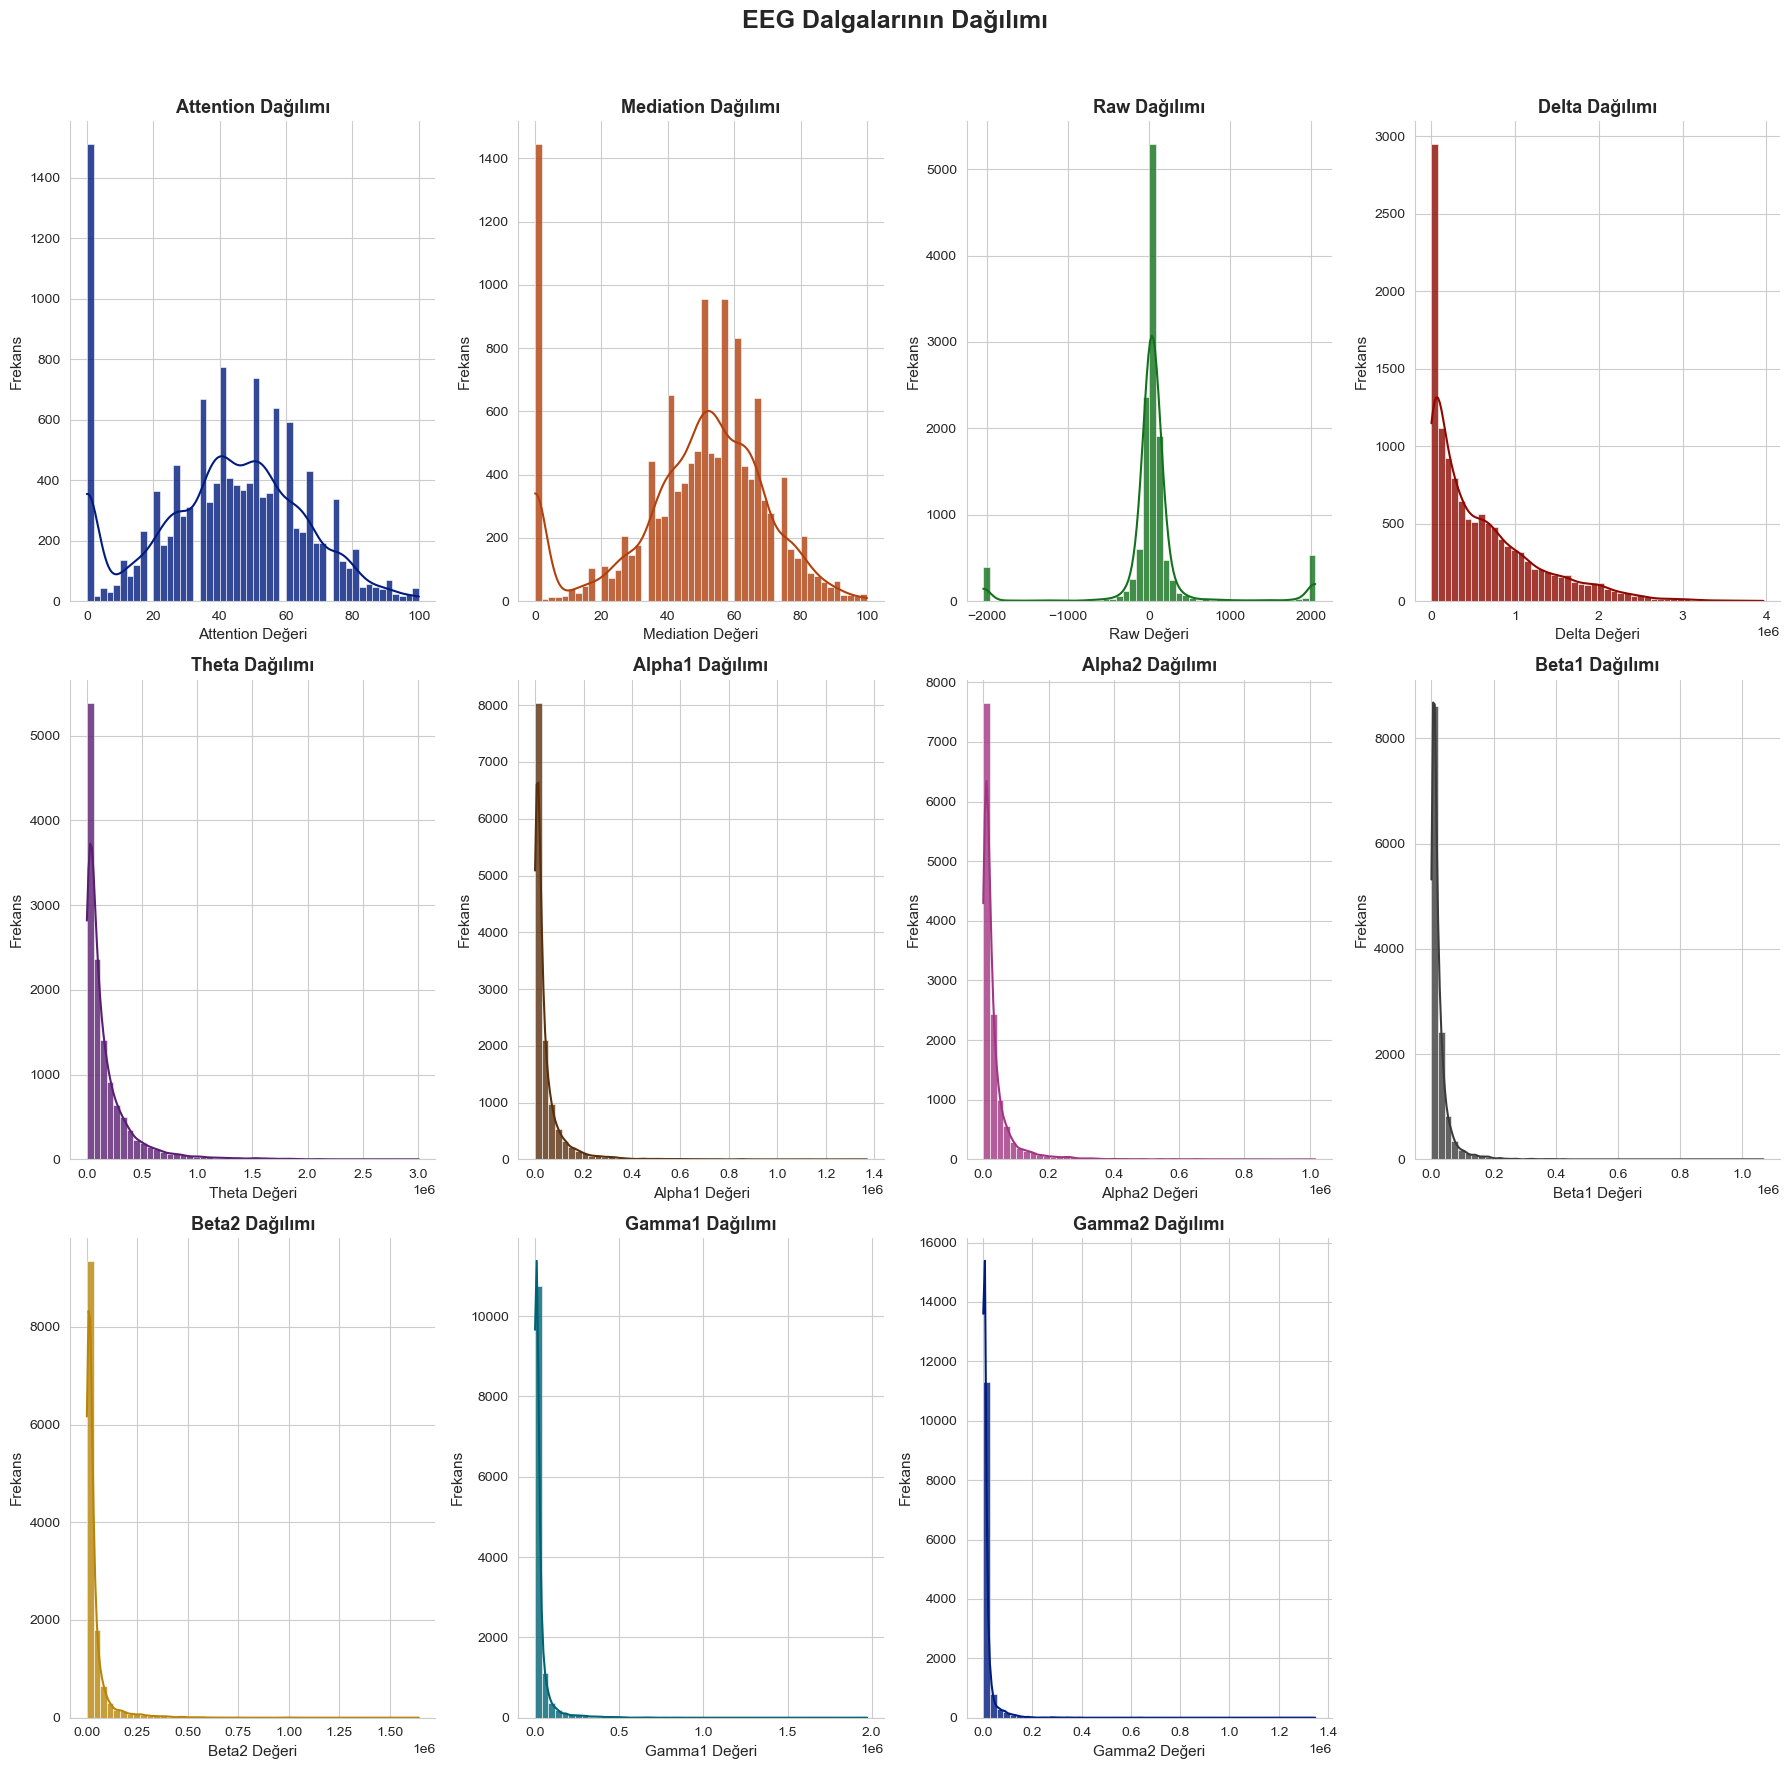

In [19]:
numeric_cols = ["Attention", "Mediation", "Raw", "Delta", "Theta",
                "Alpha1", "Alpha2", "Beta1", "Beta2", "Gamma1", "Gamma2"]
numeric_cols = [c for c in numeric_cols if c in new_eeg_data.columns]

palette = sns.color_palette("dark", len(numeric_cols))

n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()
fig.suptitle("EEG Dalgalarının Dağılımı", fontsize=18, fontweight="bold")

for i, col in enumerate(numeric_cols):
    sns.histplot(data=new_eeg_data, x=col,
                 color=palette[i],
                 ax=axes[i], kde=True, bins=50, alpha=0.8)
    axes[i].set_title(f"{col} Dağılımı", fontsize=13, fontweight="bold")
    axes[i].set_xlabel(f"{col} Değeri", fontsize=11)
    axes[i].set_ylabel("Frekans", fontsize=11)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 3.2 Adaylara Göre Odaklanılan Videolardaki Dağılımı

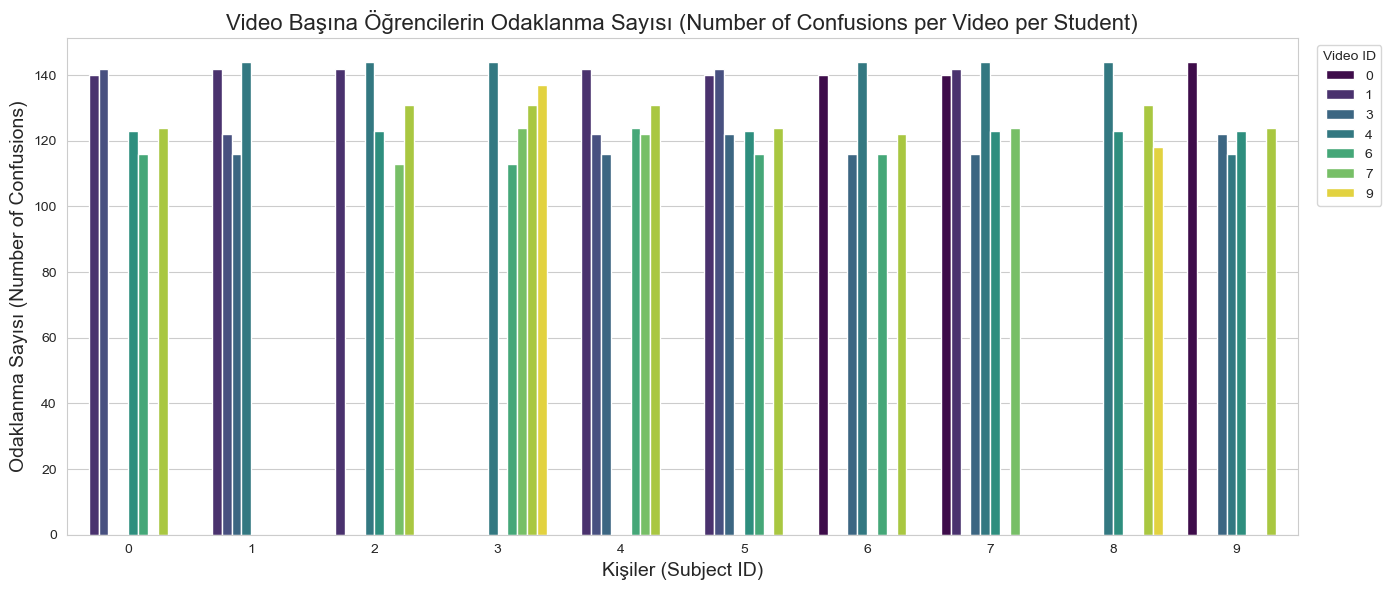

In [20]:
video_ohe_cols = [c for c in new_eeg_data.columns if c.startswith("VideoID_")]

confused_rows = new_eeg_data[new_eeg_data["UserDefinedLabel"] == 1]

confusion_counts = (
    confused_rows
    .groupby("SubjectID")[video_ohe_cols]
    .sum()
    .reset_index()
    .melt(id_vars="SubjectID", var_name="VideoID", value_name="ConfusedCount")
)
confusion_counts = confusion_counts[confusion_counts["ConfusedCount"] > 0]
confusion_counts["VideoID"] = confusion_counts["VideoID"].str.replace("VideoID_", "").astype(int)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=confusion_counts,
    x="SubjectID",
    y="ConfusedCount",
    hue="VideoID",
    palette="viridis"
)
plt.xlabel("Kişiler (Subject ID)", fontsize=14)
plt.ylabel("Odaklanma Sayısı (Number of Confusions)", fontsize=14)
plt.title("Video Başına Öğrencilerin Odaklanma Sayısı (Number of Confusions per Video per Student)", fontsize=16)
plt.legend(title="Video ID", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3.3 Cinsiyete Göre Odaklanılan Videolardaki Dağılımı

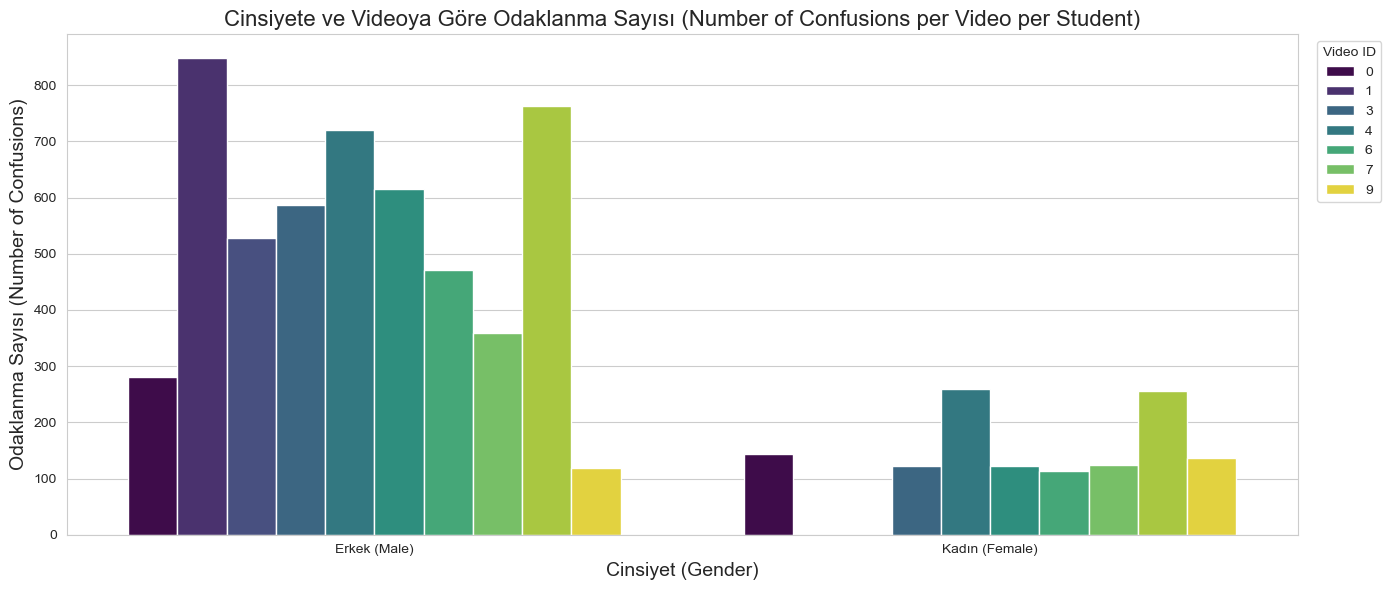

In [21]:
confusion_gender = (
    new_eeg_data[new_eeg_data["UserDefinedLabel"] == 1]
    .assign(
        Gender=lambda df: df["Gender_F"].map({1.0: "Kadın (Female)", 0.0: "Erkek (Male)"}),
        VideoID=lambda df: df[[c for c in df.columns if c.startswith("VideoID_")]].idxmax(axis=1).str.replace("VideoID_", "").astype(int)
    )
    .groupby(["Gender", "VideoID"])["UserDefinedLabel"]
    .size()
    .reset_index(name="ConfusedCount")
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=confusion_gender,
    x="Gender",
    y="ConfusedCount",
    hue="VideoID",
    palette="viridis"
)
plt.xlabel("Cinsiyet (Gender)", fontsize=14)
plt.ylabel("Odaklanma Sayısı (Number of Confusions)", fontsize=14)
plt.title("Cinsiyete ve Videoya Göre Odaklanma Sayısı (Number of Confusions per Video per Student)", fontsize=16)
plt.legend(title="Video ID", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3.4 Etnik Kökene Göre Odaklanılan Video Dağılımı

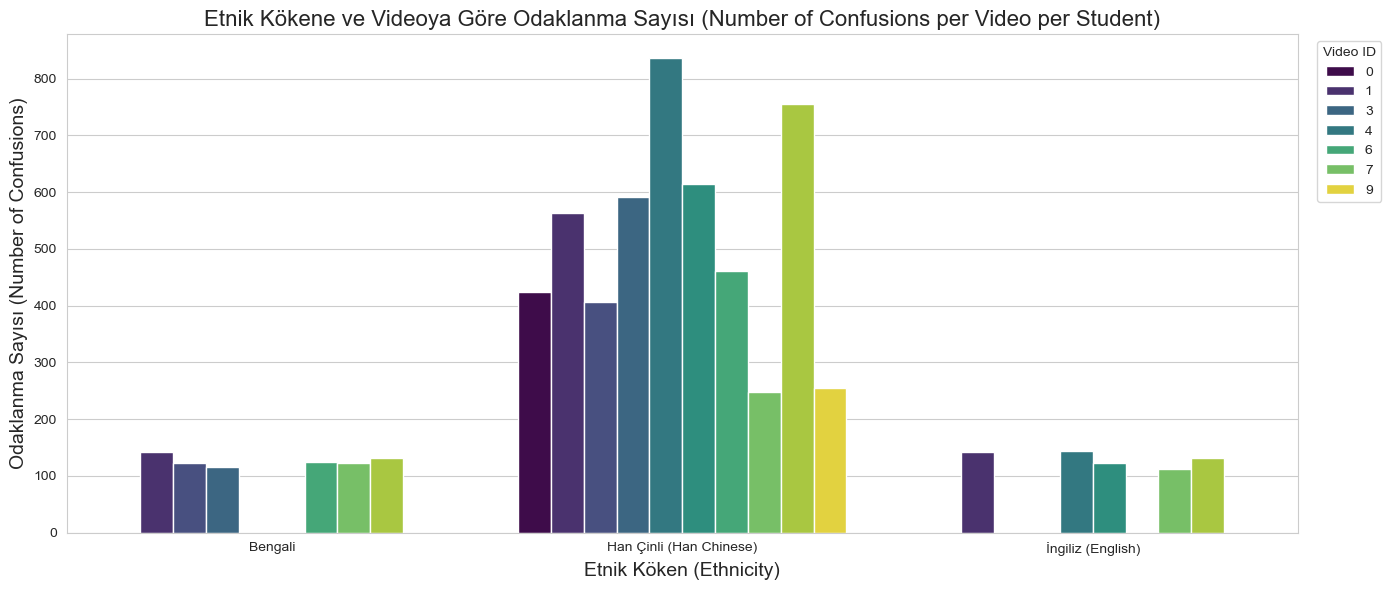

In [22]:
ethnicity_ohe_cols = [c for c in new_eeg_data.columns if c.startswith("Ethnicity_")]
ethnicity_label_map = {
    "Ethnicity_Bengali": "Bengali",
    "Ethnicity_English": "İngiliz (English)",
    "Ethnicity_Han Chinese": "Han Çinli (Han Chinese)"
}

confusion_ethnicity = (
    new_eeg_data[new_eeg_data["UserDefinedLabel"] == 1]
    .assign(
        Ethnicity=lambda df: df[ethnicity_ohe_cols].idxmax(axis=1).map(ethnicity_label_map),
        VideoID=lambda df: df[[c for c in df.columns if c.startswith("VideoID_")]].idxmax(axis=1).str.replace("VideoID_", "").astype(int)
    )
    .groupby(["Ethnicity", "VideoID"])["UserDefinedLabel"]
    .size()
    .reset_index(name="ConfusedCount")
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=confusion_ethnicity,
    x="Ethnicity",
    y="ConfusedCount",
    hue="VideoID",
    palette="viridis"
)
plt.xlabel("Etnik Köken (Ethnicity)", fontsize=14)
plt.ylabel("Odaklanma Sayısı (Number of Confusions)", fontsize=14)
plt.title("Etnik Kökene ve Videoya Göre Odaklanma Sayısı (Number of Confusions per Video per Student)", fontsize=16)
plt.legend(title="Video ID", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 4. Aykırı Değer Analizi

## 4.1 Tek Değişkenli Aykırı Değer Analizi

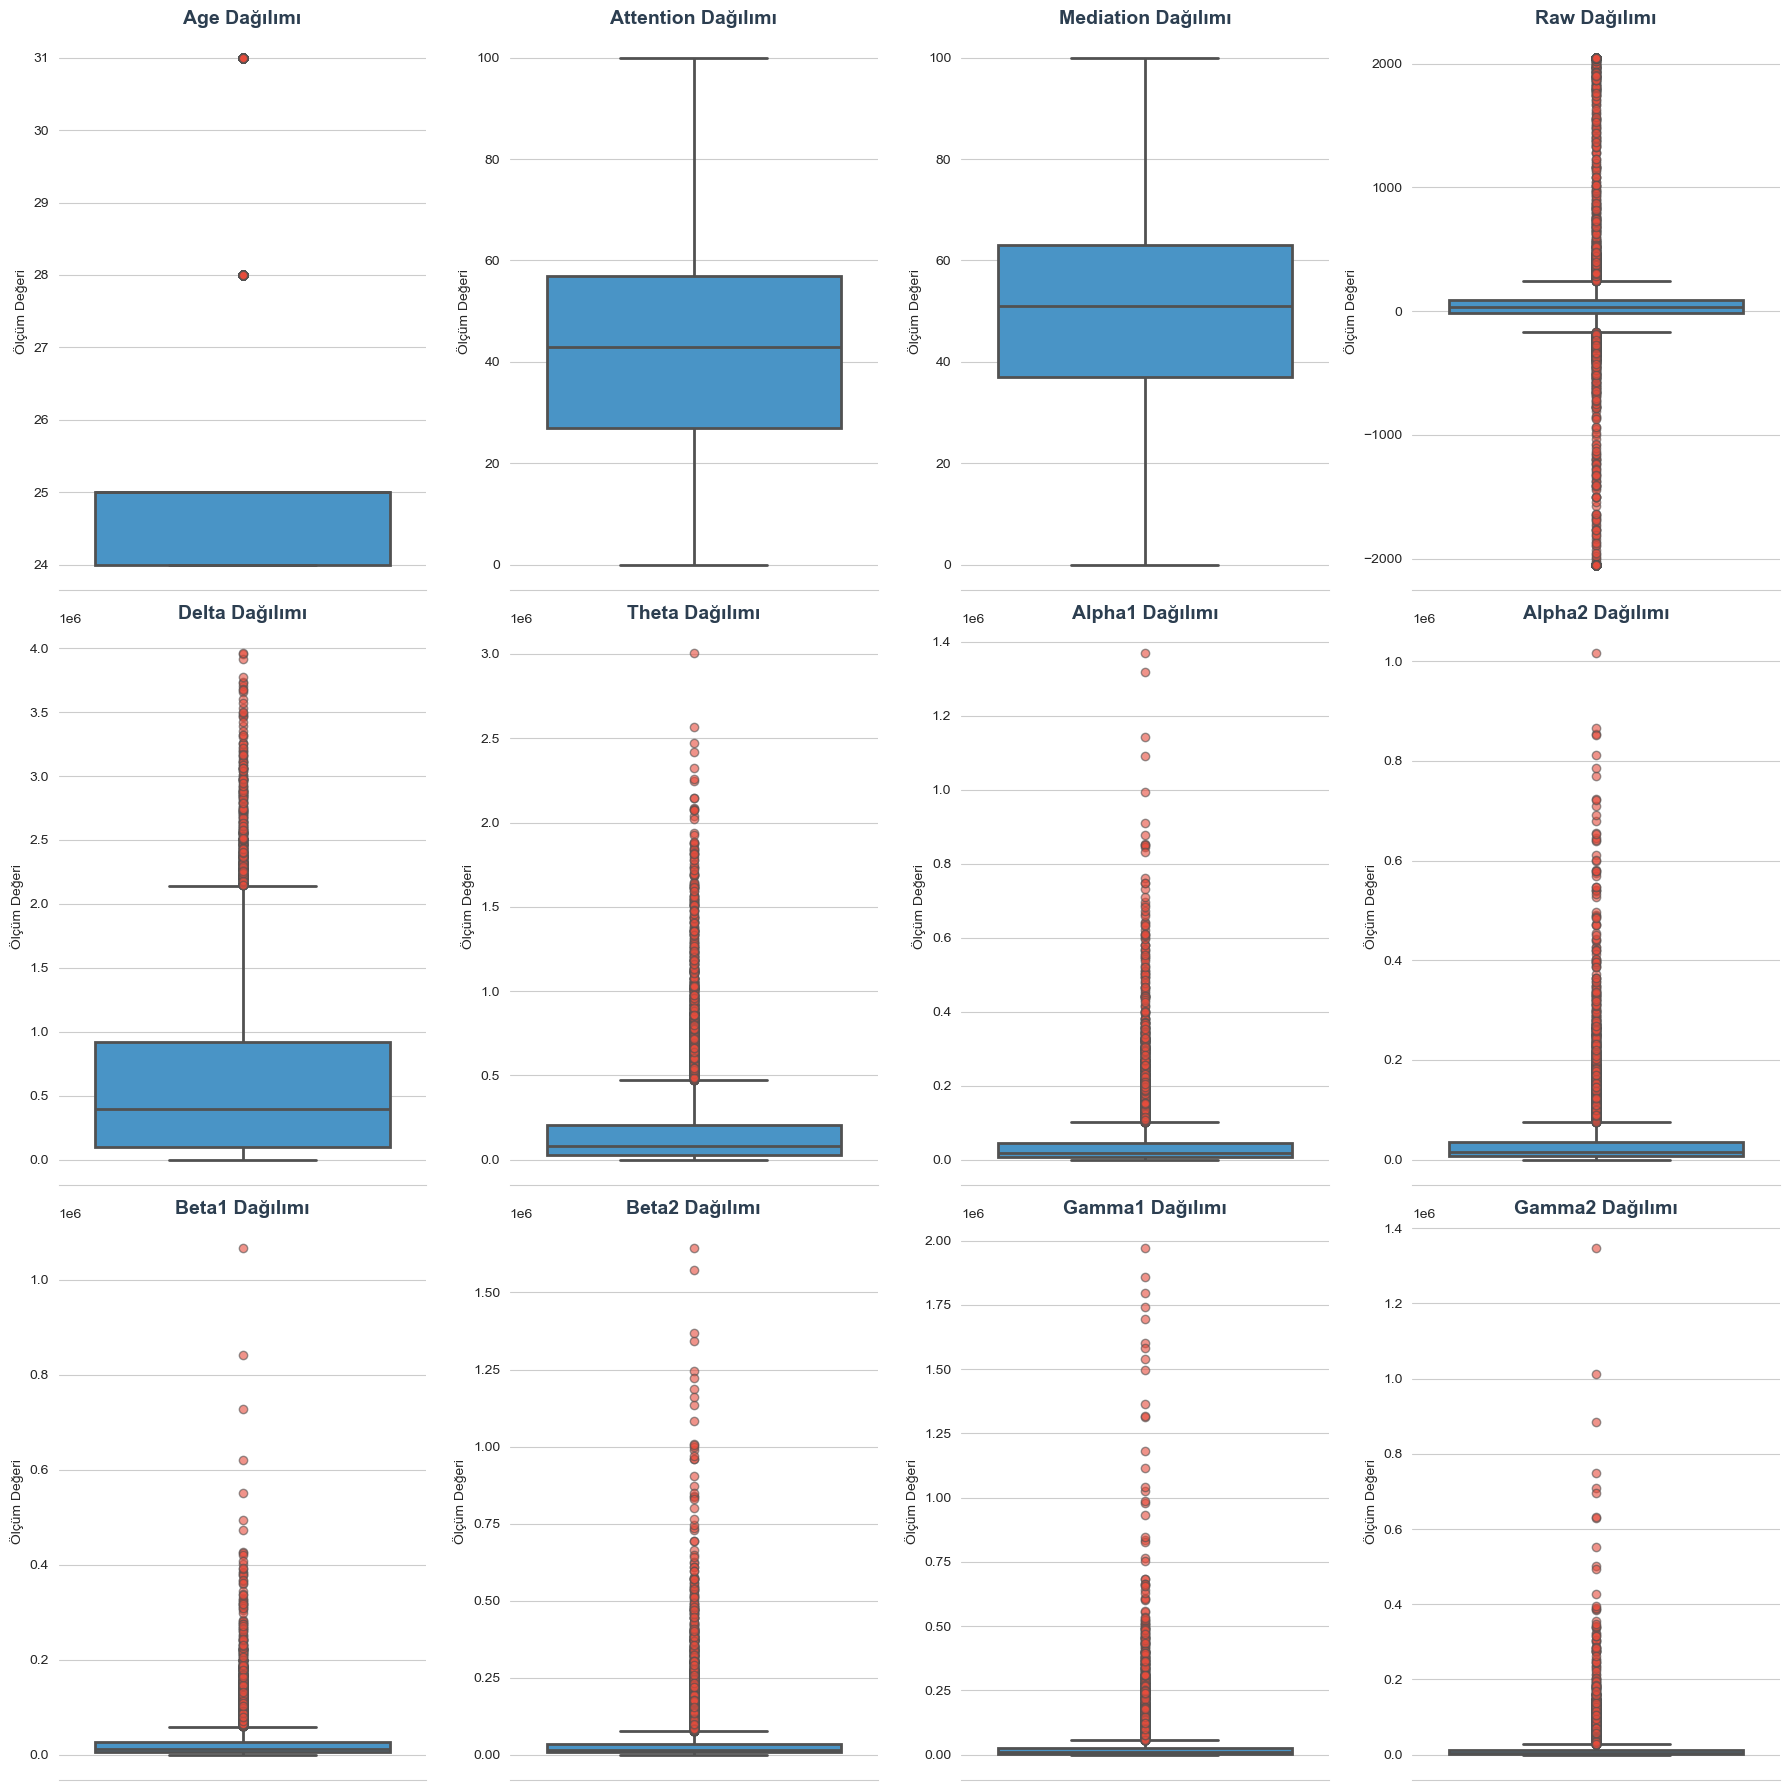

In [23]:
num_features = ['Age', 'Attention', 'Mediation', 'Raw', 'Delta', 'Theta', 'Alpha1', 'Alpha2', 'Beta1', 'Beta2', 'Gamma1', 'Gamma2']

n_cols = 4
n_rows = math.ceil(len(num_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()
sns.set_style("whitegrid")

for i, feature in enumerate(num_features):
    sns.boxplot(y=new_eeg_data[feature], color="#3498db", ax=axes[i],
                linewidth=2, fliersize=6,
                flierprops={"marker": "o", "markerfacecolor": "#e74c3c", "alpha": 0.6})
    
    axes[i].set_title(f"{feature} Dağılımı", fontsize=14, fontweight='bold', color="#2c3e50")
    axes[i].set_ylabel("Ölçüm Değeri")

# Boş kalan eksenleri temizle
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
sns.despine(left=True)
plt.show()

In [24]:
def outlier_detect_procces(data, columns):
    initial_rows = len(data)
    for column in columns:
        print(f"Processing Feature: {column}")
        lower = data[column].quantile(0.01)
        upper = data[column].quantile(0.99)
        
        outlier_mask = (data[column] < lower) | (data[column] > upper)
        num_outliers = outlier_mask.sum()
        data = data[~outlier_mask]
        print(f"Removed {num_outliers} outliers. Remaining: {len(data)}")
    
    total_removed = initial_rows - len(data)
    print(f"\n--- Total Rows Removed: {total_removed} ---")
    return data

# 5. Korelasyon Analizi

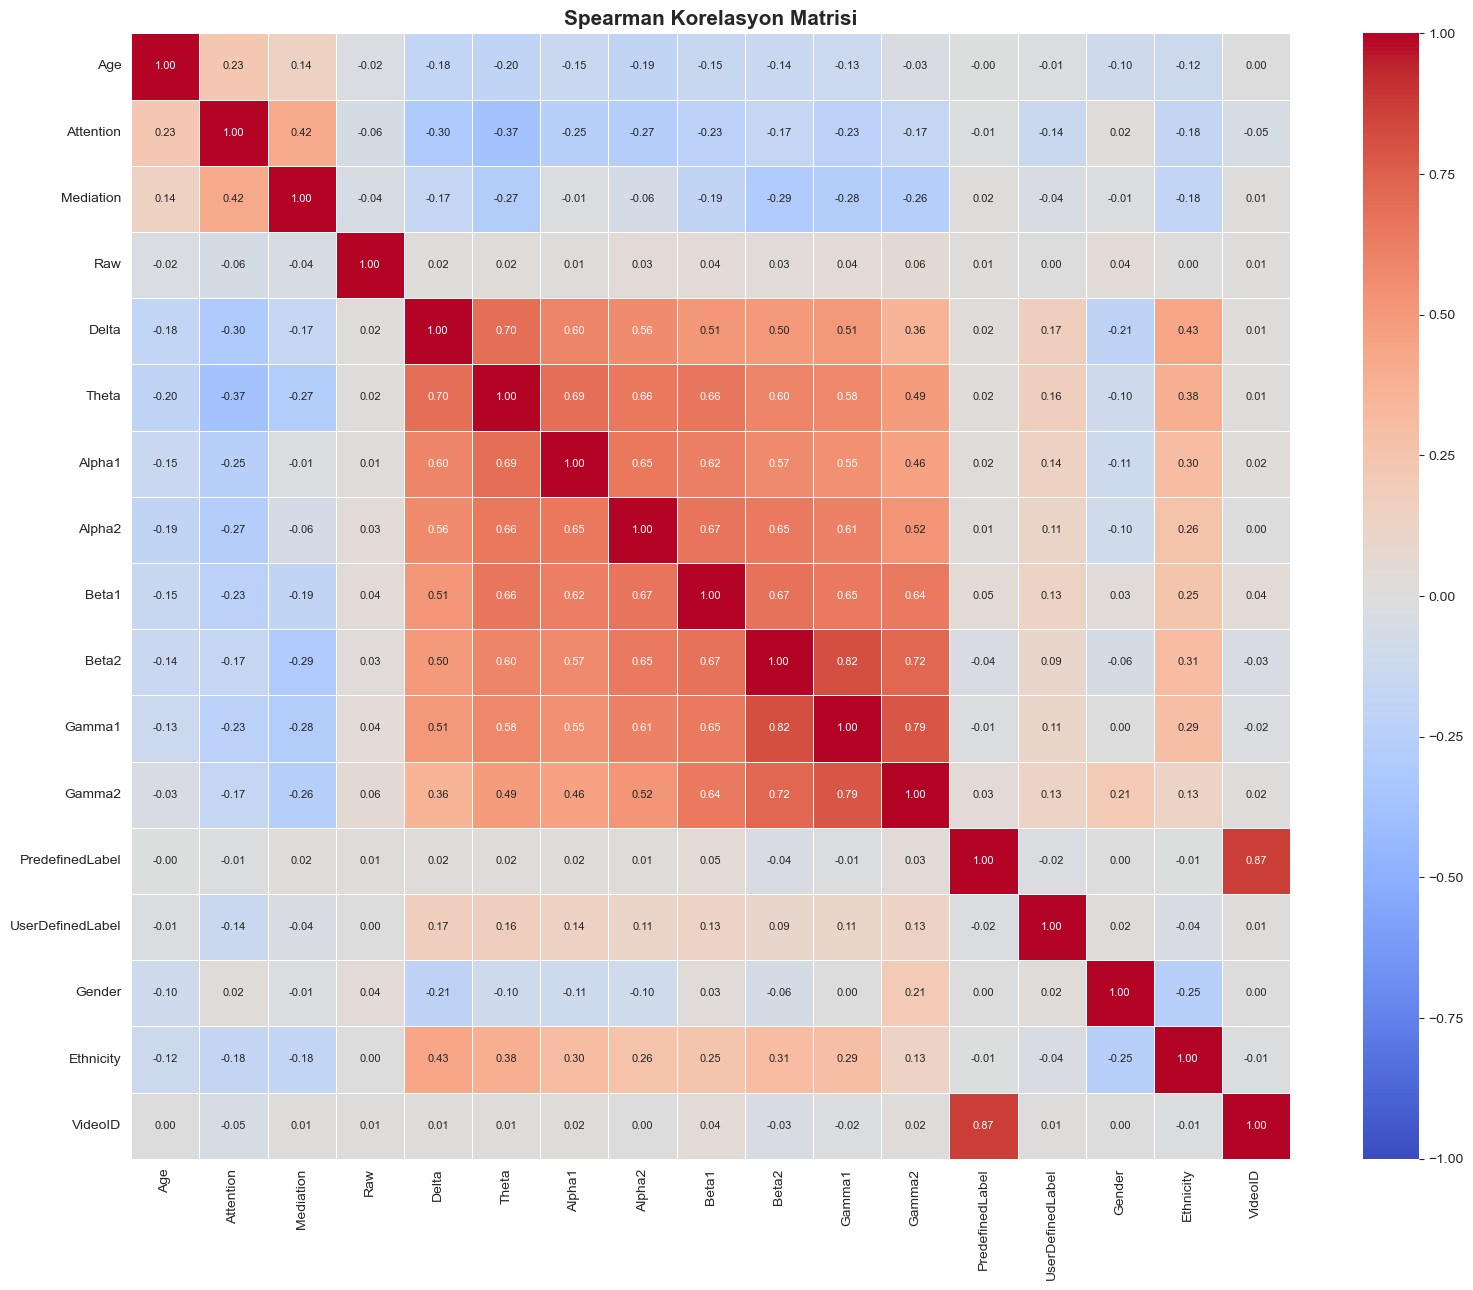

In [25]:
df_corr = new_eeg_data.copy()

df_corr['Gender'] = df_corr['Gender_M'].astype(int)

ethnicity_cols = [c for c in df_corr.columns if c.startswith('Ethnicity_')]
df_corr['Ethnicity'] = df_corr[ethnicity_cols].values.argmax(axis=1)

video_cols = [c for c in df_corr.columns if c.startswith('VideoID_')]
df_corr['VideoID'] = df_corr[video_cols].values.argmax(axis=1)

drop_cols = ['SubjectID'] + ethnicity_cols + video_cols + ['Gender_F', 'Gender_M']
df_corr = df_corr.drop(columns=drop_cols)

corr_matrix = df_corr.corr(method="spearman")

plt.figure(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Spearman Korelasyon Matrisi", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# 6. Hipotez Varsayım Testleri

## 6.1 Normallik Testi (Shapiro-Wilk)

In [26]:
BANDS = ['Delta', 'Theta', 'Alpha1', 'Alpha2', 'Beta1', 'Beta2', 'Gamma1', 'Gamma2']
test_cols = ['Attention', 'Mediation'] + BANDS
normally_sonuc = []

for col in test_cols:
    sample = new_eeg_data[col].dropna().sample(5000, random_state=42)
    stat, p = shapiro(sample)
    normally_sonuc.append({
        'Değişken': col,
        'W istatistiği': round(stat, 4),
        'p-değeri': f'{p:.2e}',
        'Dağılım': 'Normal DEĞİL ✗' if p < 0.05 else 'Normal ✓'
    })
 
df_normaly = pd.DataFrame(normally_sonuc)
print(df_normaly.to_string(index=False))
print("\n→ Tüm değişkenler normal dağılmıyor.")
print("→ Parametrik olmayan testler (Spearman, Mann-Whitney U) kullanılacak.\n")

 Değişken  W istatistiği p-değeri        Dağılım
Attention         0.9688 1.30e-31 Normal DEĞİL ✗
Mediation         0.9322 6.68e-43 Normal DEĞİL ✗
    Delta         0.8498 2.63e-56 Normal DEĞİL ✗
    Theta         0.6437 5.40e-73 Normal DEĞİL ✗
   Alpha1         0.5400 2.34e-78 Normal DEĞİL ✗
   Alpha2         0.4624 1.00e-81 Normal DEĞİL ✗
    Beta1         0.5736 9.60e-77 Normal DEĞİL ✗
    Beta2         0.4424 1.59e-82 Normal DEĞİL ✗
   Gamma1         0.2811 3.38e-88 Normal DEĞİL ✗
   Gamma2         0.3010 1.46e-87 Normal DEĞİL ✗

→ Tüm değişkenler normal dağılmıyor.
→ Parametrik olmayan testler (Spearman, Mann-Whitney U) kullanılacak.



## 6.2 SPEARMAN KORELASYON: EEG BANTLARI × ATTENTION

AS1 — SPEARMAN KORELASYON: EEG Bantları × Attention
H0: EEG bandı ile Attention arasında anlamlı ilişki yoktur.
H1: EEG bandı ile Attention arasında anlamlı ilişki vardır.
Bonferroni eşiği: α = 0.05 / 8 = 0.0063

  Bant  Spearman ρ  p-değeri Bonf. eşik Anlamlı? İlişki gücü
 Delta     -0.2985 7.58e-262     0.0063   ✓ Evet       zayıf
 Theta     -0.3742  0.00e+00     0.0063   ✓ Evet        orta
Alpha1     -0.2520 9.45e-185     0.0063   ✓ Evet       zayıf
Alpha2     -0.2668 1.05e-207     0.0063   ✓ Evet       zayıf
 Beta1     -0.2322 1.84e-156     0.0063   ✓ Evet       zayıf
 Beta2     -0.1718  1.99e-85     0.0063   ✓ Evet       zayıf
Gamma1     -0.2278 2.00e-150     0.0063   ✓ Evet       zayıf
Gamma2     -0.1663  4.34e-80     0.0063   ✓ Evet       zayıf


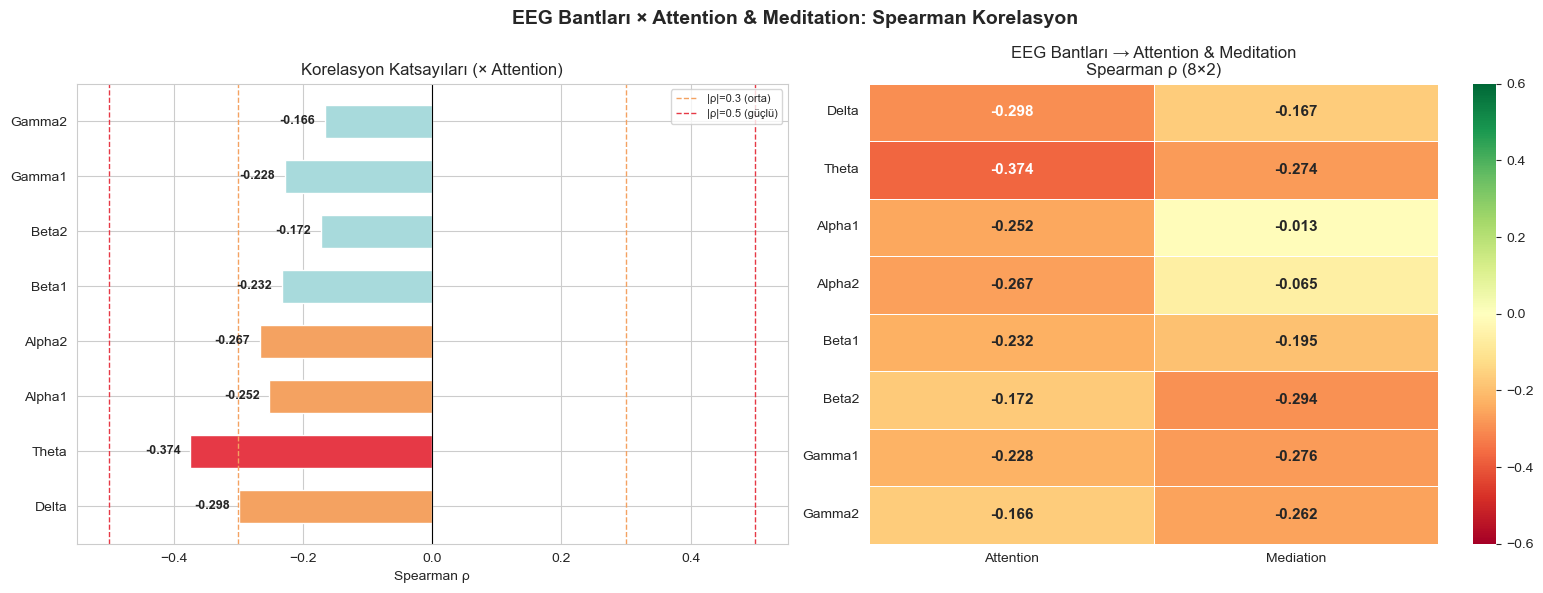

In [37]:
print("=" * 65)
print("AS1 — SPEARMAN KORELASYON: EEG Bantları × Attention")
print("=" * 65)
print(f"H0: EEG bandı ile Attention arasında anlamlı ilişki yoktur.")
print(f"H1: EEG bandı ile Attention arasında anlamlı ilişki vardır.")
print(f"Bonferroni eşiği: α = 0.05 / {len(BANDS)} = {0.05/len(BANDS):.4f}\n")

alpha_bonf_as1 = 0.05 / len(BANDS)
as1_sonuc = []

for band in BANDS:
    rho, p = spearmanr(new_eeg_data[band], new_eeg_data['Attention'])
    guc = 'güçlü' if abs(rho) > 0.5 else 'orta' if abs(rho) > 0.3 else 'zayıf'
    as1_sonuc.append({
        'Bant': band,
        'Spearman ρ': round(rho, 4),
        'p-değeri': f'{p:.2e}',
        'Bonf. eşik': f'{alpha_bonf_as1:.4f}',
        'Anlamlı?': '✓ Evet' if p < alpha_bonf_as1 else '✗ Hayır',
        'İlişki gücü': guc
    })

df_as1 = pd.DataFrame(as1_sonuc)
print(df_as1.to_string(index=False))

# --- AS1 Görselleştirme ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EEG Bantları × Attention & Meditation: Spearman Korelasyon', fontsize=14, fontweight='bold')

# Sol: Bar chart (rho değerleri — Attention)
rho_vals = df_as1['Spearman ρ'].values
x_lo = min(float(rho_vals.min()) - 0.1, -0.55)
x_hi = max(float(rho_vals.max()) + 0.1,  0.55)

def bar_color(r):
    if abs(r) > 0.35:
        return '#E63946'
    elif abs(r) > 0.25:
        return '#F4A261'
    else:
        return '#A8DADC'

colors = [bar_color(r) for r in rho_vals]
bars = axes[0].barh(BANDS, rho_vals, color=colors, edgecolor='white', height=0.6)
axes[0].axvline(0, color='black', linewidth=0.8)
for sign in [-1, 1]:
    axes[0].axvline(sign * 0.3, color='#F4A261', linewidth=1, linestyle='--',
                    label='|ρ|=0.3 (orta)' if sign == 1 else '')
    axes[0].axvline(sign * 0.5, color='#E63946', linewidth=1, linestyle='--',
                    label='|ρ|=0.5 (güçlü)' if sign == 1 else '')
for bar, rho in zip(bars, rho_vals):
    offset = 0.015 if rho >= 0 else -0.015
    ha = 'left' if rho >= 0 else 'right'
    axes[0].text(rho + offset, bar.get_y() + bar.get_height() / 2,
                 f'{rho:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')
axes[0].set_xlabel('Spearman ρ')
axes[0].set_title('Korelasyon Katsayıları (× Attention)')
axes[0].legend(fontsize=8)
axes[0].set_xlim(x_lo, x_hi)

# Sağ: Heatmap — EEG Bantları × Attention + Mediation (8×2)
corr_cols = BANDS + ['Attention', 'Mediation']
corr_subset = new_eeg_data[corr_cols].corr(method='spearman').loc[BANDS, ['Attention', 'Mediation']]
sns.heatmap(corr_subset, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=axes[1], annot_kws={'size': 11, 'fontweight': 'bold'},
            vmin=-0.6, vmax=0.6, linewidths=0.5, linecolor='white')
axes[1].set_title('EEG Bantları → Attention & Meditation\nSpearman ρ (8×2)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 6.3 SPEARMAN KORELASYON: ATTENTION × MEDIATION

AS2 – SPEARMAN KORELASYON: Attention × Mediation
H0: Attention ve Mediation arasında anlamlı ilişki yoktur.
H1: Attention ve Mediation arasında anlamlı ilişki vardır.
Test düzeyi: α = 0.05 (AS2, bağımsız araştırma sorusu — tek test)

Spearman ρ  : 0.4156
p-değeri    : 0.00e+00
Karar       : H0 REDDEDİLDİ ✔  (α=0.05)
İlişki yönü : pozitif
İlişki gücü : orta  (|ρ| = 0.416)

Not: AS1 ve AS2 farklı araştırma sorularını (EEG→Attention ve Attention↔Meditation)
     ele aldığından her biri bağımsız test ailesi olarak kabul edilir.

Yorum: Attention arttığında Mediation de artıyor – orta pozitif ilişki.

=== Bireysel Tutarlılık (per-subject) ===
 SubjectID      ρ            p  Anlamlı
         9 -0.107 1.451808e-04     True
         2 -0.096 5.489762e-04     True
         7  0.045 1.076899e-01    False
         0  0.067 1.787441e-02     True
         5  0.233 5.312914e-17     True
         8  0.265 4.785262e-22     True
         4  0.310 3.788557e-30     True
         1  0.322 1.033798e-32    

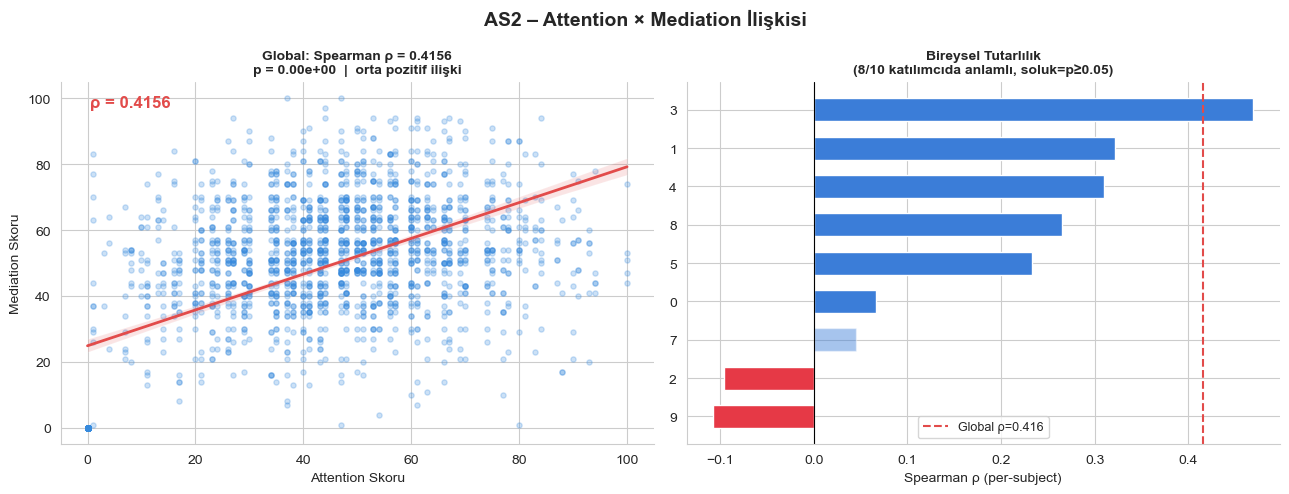

In [28]:
print("=" * 65)
print("AS2 – SPEARMAN KORELASYON: Attention × Mediation")
print("=" * 65)
print("H0: Attention ve Mediation arasında anlamlı ilişki yoktur.")
print("H1: Attention ve Mediation arasında anlamlı ilişki vardır.")
print("Test düzeyi: α = 0.05 (AS2, bağımsız araştırma sorusu — tek test)\n")

rho_as2, p_as2 = spearmanr(new_eeg_data['Attention'], new_eeg_data['Mediation'])

guc_as2 = 'güçlü' if abs(rho_as2) > 0.5 else 'orta' if abs(rho_as2) > 0.3 else 'zayıf'
yon_as2 = 'pozitif' if rho_as2 > 0 else 'negatif'

print(f"Spearman ρ  : {rho_as2:.4f}")
print(f"p-değeri    : {p_as2:.2e}")
print(f"Karar       : {'H0 REDDEDİLDİ ✔' if p_as2 < 0.05 else 'H0 KABUL EDİLDİ ✗'}  (α=0.05)")
print(f"İlişki yönü : {yon_as2}")
print(f"İlişki gücü : {guc_as2}  (|ρ| = {abs(rho_as2):.3f})")
print(f"\nNot: AS1 ve AS2 farklı araştırma sorularını (EEG→Attention ve Attention↔Meditation)")
print("     ele aldığından her biri bağımsız test ailesi olarak kabul edilir.")
print(f"\nYorum: Attention arttığında Mediation {'de artıyor' if rho_as2 > 0 else 'azalıyor'} – {guc_as2} {yon_as2} ilişki.")

# --- Per-Subject Korelasyon (tutarlılık analizi) ---
subject_rhos = []
for subj in new_eeg_data['SubjectID'].unique():
    sub_df = new_eeg_data[new_eeg_data['SubjectID'] == subj]
    if len(sub_df) >= 10:
        r_s, p_s = spearmanr(sub_df['Attention'], sub_df['Mediation'])
        subject_rhos.append({'SubjectID': subj, 'ρ': round(r_s, 3), 'p': p_s,
                              'Anlamlı': p_s < 0.05})

df_subj = pd.DataFrame(subject_rhos).sort_values('ρ')
n_sig = df_subj['Anlamlı'].sum()
print(f"\n=== Bireysel Tutarlılık (per-subject) ===")
print(df_subj.to_string(index=False))
print(f"\n→ {n_sig}/{len(df_subj)} katılımcıda Attention↔Meditation ilişkisi anlamlı (α=0.05)")
tutarli = 'tutarlı' if n_sig / len(df_subj) >= 0.6 else 'tutarsız'
print(f"→ Bireyler arası örüntü: {tutarli}")

# --- Görselleştirme: 2 panel ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('AS2 – Attention × Mediation İlişkisi', fontsize=14, fontweight='bold')

# Sol: Global scatter + regresyon
sample_idx = new_eeg_data.sample(min(2000, len(new_eeg_data)), random_state=42).index
sns.regplot(
    x=new_eeg_data.loc[sample_idx, 'Attention'],
    y=new_eeg_data.loc[sample_idx, 'Mediation'],
    ax=axes[0],
    scatter_kws={'alpha': 0.25, 'color': '#378ADD', 's': 14},
    line_kws={'color': '#E24B4A', 'linewidth': 2}
)
axes[0].set_title(
    f'Global: Spearman ρ = {rho_as2:.4f}\np = {p_as2:.2e}  |  {guc_as2} {yon_as2} ilişki',
    fontsize=10, fontweight='bold'
)
axes[0].set_xlabel('Attention Skoru')
axes[0].set_ylabel('Mediation Skoru')
axes[0].text(0.05, 0.93, f'ρ = {rho_as2:.4f}', transform=axes[0].transAxes,
             fontsize=12, fontweight='bold', color='#E24B4A')
sns.despine(ax=axes[0])

# Sağ: Per-subject bar chart
bar_colors = ['#3B7DD8' if v >= 0 else '#E63946' for v in df_subj['ρ']]
bar_alphas = [1.0 if a else 0.45 for a in df_subj['Anlamlı']]
bars2 = axes[1].barh([str(s) for s in df_subj['SubjectID']], df_subj['ρ'],
                     color=bar_colors, alpha=0.8, edgecolor='white', height=0.6)
for bar, alpha_val in zip(bars2, bar_alphas):
    bar.set_alpha(alpha_val)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(rho_as2, color='#E24B4A', linewidth=1.5, linestyle='--',
                label=f'Global ρ={rho_as2:.3f}')
axes[1].set_xlabel('Spearman ρ (per-subject)')
axes[1].set_title(f'Bireysel Tutarlılık\n({n_sig}/{len(df_subj)} katılımcıda anlamlı, soluk=p≥0.05)',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

## 6.4 MANN-WHITNEY U: PredefinedLabel 0 vs 1

AS3 – MANN-WHITNEY U: UserDefinedLabel 0 vs 1
H0: İki grup arasında değişkenin dağılımı aynıdır.
H1: İki grup arasında değişkenin dağılımı farklıdır.
Bonferroni eşiği: α = 0.05 / 10 = 0.0050

Grup 0 (karışık / confused): 6,244 kayıt
Grup 1 (net / not confused): 6,567 kayıt

 Değişken  Grup 0 Medyan  Grup 1 Medyan  U istatistiği p-değeri  Etki büy. (r)   Güç Anlamlı?
    Delta       281487.0       546788.0       16584762 3.24e-78         0.1911 küçük   ✔ Evet
    Theta        63499.0       104661.0       16608684 2.75e-77         0.1899 küçük   ✔ Evet
   Alpha1        14447.0        21327.0       17267221 6.37e-54         0.1578 küçük   ✔ Evet
   Alpha2        13127.5        17618.0       17789528 1.94e-38         0.1323 küçük   ✔ Evet
    Beta1        11135.5        14644.0       17486205 4.21e-47         0.1471 küçük   ✔ Evet
    Beta2        13854.0        17706.0       18428121 3.67e-23         0.1012 küçük   ✔ Evet
   Gamma1         8372.5        11259.0       17925134 7.38e-35    

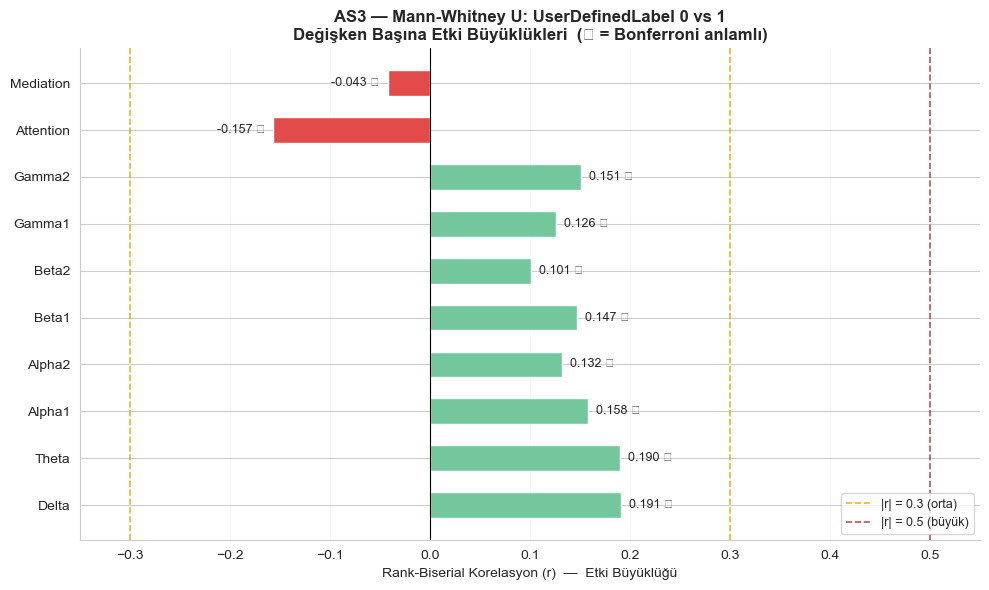

In [29]:
print("=" * 65)
print("AS3 – MANN-WHITNEY U: UserDefinedLabel 0 vs 1")
print("=" * 65)
print("H0: İki grup arasında değişkenin dağılımı aynıdır.")
print("H1: İki grup arasında değişkenin dağılımı farklıdır.")

test_vars = BANDS + ['Attention', 'Mediation']
alpha_bonf_as3 = 0.05 / len(test_vars)
print(f"Bonferroni eşiği: α = 0.05 / {len(test_vars)} = {alpha_bonf_as3:.4f}\n")

g0 = new_eeg_data[new_eeg_data['UserDefinedLabel'] == 0]
g1 = new_eeg_data[new_eeg_data['UserDefinedLabel'] == 1]
print(f"Grup 0 (karışık / confused): {len(g0):,} kayıt")
print(f"Grup 1 (net / not confused): {len(g1):,} kayıt\n")

as3_sonuc = []
for var in test_vars:
    u_stat, p = mannwhitneyu(g0[var], g1[var], alternative='two-sided')
    n1, n2 = len(g0[var].dropna()), len(g1[var].dropna())
    r_effect = 1 - (2 * u_stat) / (n1 * n2)
    guc = 'büyük' if abs(r_effect) > 0.5 else 'orta' if abs(r_effect) > 0.3 else 'küçük'
    anlamli = p < alpha_bonf_as3
    as3_sonuc.append({
        'Değişken':       var,
        'Grup 0 Medyan':  round(g0[var].median(), 2),
        'Grup 1 Medyan':  round(g1[var].median(), 2),
        'U istatistiği':  int(u_stat),
        'p-değeri':       f'{p:.2e}',
        'Etki büy. (r)':  round(r_effect, 4),
        'Güç':            guc,
        'Anlamlı?':       '✔ Evet' if anlamli else '✗ Hayır'
    })

df_as3 = pd.DataFrame(as3_sonuc)
print(df_as3.to_string(index=False))

# --- AS3 Görselleştirme: Etki Büyüklüğü Bar Chart ---
fig, ax = plt.subplots(figsize=(10, 6))

def as3_color(row):
    if row['Anlamlı?'] != '✔ Evet':
        return '#CCCCCC'
    r = row['Etki büy. (r)']
    if r < 0:
        return '#E24B4A'
    elif abs(r) > 0.3:
        return '#2D6A4F'
    else:
        return '#74C69D'

colors_as3 = [as3_color(row) for _, row in df_as3.iterrows()]
bars_as3 = ax.barh(df_as3['Değişken'], df_as3['Etki büy. (r)'],
                   color=colors_as3, edgecolor='white', height=0.55)

r_vals = df_as3['Etki büy. (r)'].values
x_lo = min(float(r_vals.min()) - 0.08, -0.35)
x_hi = max(float(r_vals.max()) + 0.08,  0.55)

ax.axvline(0,    color='black',   linewidth=0.8)
for sign in [-1, 1]:
    ax.axvline(sign * 0.3, color='#E8A000', linewidth=1.2, linestyle='--', alpha=0.8,
               label='|r| = 0.3 (orta)' if sign == 1 else '')
    ax.axvline(sign * 0.5, color='#A32D2D', linewidth=1.2, linestyle='--', alpha=0.8,
               label='|r| = 0.5 (büyük)' if sign == 1 else '')

for bar, (_, row) in zip(bars_as3, df_as3.iterrows()):
    r   = row['Etki büy. (r)']
    sig = ' ★' if row['Anlamlı?'] == '✔ Evet' else ''
    ha  = 'left' if r >= 0 else 'right'
    offset = 0.008 if r >= 0 else -0.008
    ax.text(r + offset, bar.get_y() + bar.get_height() / 2,
            f'{r:.3f}{sig}', va='center', ha=ha, fontsize=9)

ax.set_xlabel('Rank-Biserial Korelasyon (r)  —  Etki Büyüklüğü')
ax.set_title('AS3 — Mann-Whitney U: UserDefinedLabel 0 vs 1\n'
             'Değişken Başına Etki Büyüklükleri  (★ = Bonferroni anlamlı)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(x_lo, x_hi)
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='x', alpha=0.2, linewidth=0.5)
sns.despine()
plt.tight_layout()
plt.show()

# 7. Model Oluşturma ve Eğitimi

In [30]:
EEG_data = new_eeg_data[["Attention","Mediation","Raw","Delta","Theta","Alpha1","Alpha2","Beta1","Beta2","Gamma1","Gamma2","UserDefinedLabel"]].copy()
EEG_data

,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,UserDefinedLabel
0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0
1,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0
2,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0
3,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0
4,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
12806,64.0,38.0,-39.0,127574.0,9951.0,709.0,21732.0,3872.0,39728.0,2598.0,960.0,0.0
12807,61.0,35.0,-275.0,323061.0,797464.0,153171.0,145805.0,39829.0,571280.0,36574.0,10010.0,0.0
12808,60.0,29.0,-426.0,680989.0,154296.0,40068.0,39122.0,10966.0,26975.0,20427.0,2024.0,0.0
12809,60.0,29.0,-84.0,366269.0,27346.0,11444.0,9932.0,1939.0,3283.0,12323.0,1764.0,0.0


In [31]:
X = EEG_data.drop(columns=["UserDefinedLabel"]).copy()
y = EEG_data["UserDefinedLabel"]

In [32]:
print(f"X Shape: ",X.shape)
print(f"y Shape: ",y.shape)

X Shape:  (12811, 11)
y Shape:  (12811,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = RobustScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (10248, 11), X_test: (2563, 11)
y_train: (10248,), y_test: (2563,)



  LogReg — Classification Report
              precision    recall  f1-score   support

       Düşük       0.61      0.60      0.60      1298
      Yüksek       0.60      0.60      0.60      1265

    accuracy                           0.60      2563
   macro avg       0.60      0.60      0.60      2563
weighted avg       0.60      0.60      0.60      2563


  SVC — Classification Report
              precision    recall  f1-score   support

       Düşük       0.63      0.62      0.63      1298
      Yüksek       0.62      0.62      0.62      1265

    accuracy                           0.62      2563
   macro avg       0.62      0.62      0.62      2563
weighted avg       0.62      0.62      0.62      2563


  RFC — Classification Report
              precision    recall  f1-score   support

       Düşük       0.70      0.65      0.67      1298
      Yüksek       0.66      0.71      0.69      1265

    accuracy                           0.68      2563
   macro avg       0.68      0.6

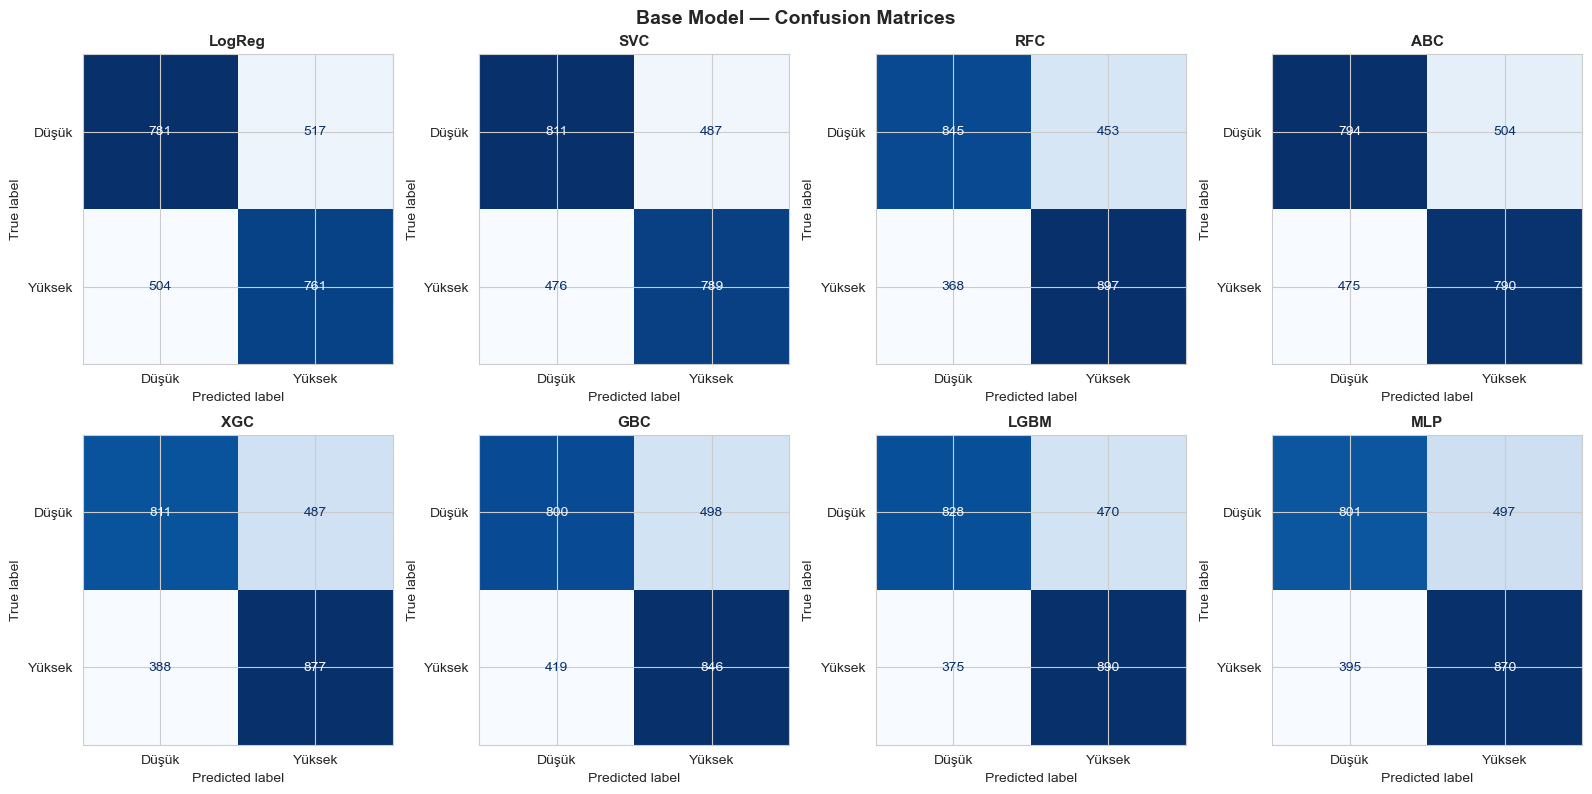


  BASE MODEL ÖZET TABLOSU
 Model  Train Accuracy  Test Accuracy  Precision  Recall  F1 (weighted)  Train-Test Gap
   RFC          1.0000         0.6797     0.6807  0.6797         0.6795          0.3203
  LGBM          0.8125         0.6703     0.6716  0.6703         0.6700          0.1421
   XGC          0.9325         0.6586     0.6599  0.6586         0.6583          0.2739
   MLP          0.6812         0.6520     0.6533  0.6520         0.6516          0.0292
   GBC          0.6761         0.6422     0.6430  0.6422         0.6420          0.0339
   SVC          0.6238         0.6243     0.6243  0.6243         0.6243         -0.0004
   ABC          0.6169         0.6180     0.6182  0.6180         0.6180         -0.0011
LogReg          0.5987         0.6016     0.6017  0.6016         0.6017         -0.0030

⚠️  Overfitting Kontrolü (Train-Test Gap > 0.05):
   RFC: gap = 0.3203 → overfitting riski!
   LGBM: gap = 0.1421 → overfitting riski!
   XGC: gap = 0.2739 → overfitting riski!


In [34]:
models = {
    "LogReg":     LogisticRegression(max_iter=1000, random_state=42),
    "SVC":        SVC(random_state=42),
    "RFC":        RandomForestClassifier(random_state=42),
    "ABC":        AdaBoostClassifier(random_state=42),
    "XGC":        XGBClassifier(eval_metric="logloss", random_state=42),
    "GBC":        GradientBoostingClassifier(random_state=42),
    "LGBM":       LGBMClassifier(random_state=42, verbose=-1),
    "MLP":        MLPClassifier(random_state=42, max_iter=500),
}

base_results = []
pipelines    = {}

n_models = len(models)
n_cols   = 4
n_rows   = math.ceil(n_models / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    pipe = Pipeline([("clf", model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

    y_pred_tr = pipe.predict(X_train)
    y_pred_te = pipe.predict(X_test)

    base_results.append({
        "Model":          name,
        "Train Accuracy": round(accuracy_score(y_train, y_pred_tr), 4),
        "Test Accuracy":  round(accuracy_score(y_test,  y_pred_te), 4),
        "Precision":      round(precision_score(y_test, y_pred_te, average="weighted"), 4),
        "Recall":         round(recall_score(y_test, y_pred_te, average="weighted"), 4),
        "F1 (weighted)":  round(f1_score(y_test, y_pred_te, average="weighted"), 4),
        "Train-Test Gap": round(
            accuracy_score(y_train, y_pred_tr) - accuracy_score(y_test, y_pred_te), 4
        ),
    })

    print(f"\n{'='*55}")
    print(f"  {name} — Classification Report")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred_te, target_names=["Düşük", "Yüksek"]))

    cm   = confusion_matrix(y_test, y_pred_te)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Düşük", "Yüksek"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name, fontweight="bold", fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Base Model — Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout(pad=1.0, h_pad=1.5, w_pad=1.0)
plt.show()

base_df = pd.DataFrame(base_results).sort_values("F1 (weighted)", ascending=False)
print("\n" + "="*70)
print("  BASE MODEL ÖZET TABLOSU")
print("="*70)
print(base_df.to_string(index=False))

print("\n⚠️  Overfitting Kontrolü (Train-Test Gap > 0.05):")
for _, row in base_df.iterrows():
    if row["Train-Test Gap"] > 0.05:
        print(f"   {row['Model']}: gap = {row['Train-Test Gap']} → overfitting riski!")

## 7.1 GridSeachCV

In [35]:
model_definitions = {
    "LogReg":     LogisticRegression(random_state=42, max_iter=2000),
    "SVC":        SVC(random_state=42, probability=True),
    "RFC":        RandomForestClassifier(random_state=42),
    "ABC":        AdaBoostClassifier(random_state=42),
    "XGC":        XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0),
    "GBC":        GradientBoostingClassifier(random_state=42),
    "LGBM":       LGBMClassifier(random_state=42, verbose=-1),
    "MLP":        MLPClassifier(random_state=42, max_iter=1000, validation_fraction=0.1),
}

param_grids = {
    "LogReg": {
            "C": [0.001, 0.01, 0.1, 1, 10, 100],
            "solver": ["lbfgs", "saga"],
            "penalty": ["l2", "l1"],
            "max_iter": [1000, 2000],
    },

    "NaiveBayes": {
        "var_smoothing": np.logspace(-11, -3, 9)
    },

    "SVC": {
        "C":     [0.01, 0.1, 1, 10, 100],
        "kernel":["rbf"],
        "gamma": ["scale", "auto", 0.01, 0.1],
    },

    "RFC": {
        "n_estimators":          [200, 400],
        "max_depth":             [5, 8, 12, 15],
        "min_samples_leaf":      [5, 10, 20],
        "max_features":          ["sqrt", "log2"],
        "criterion":             ["gini", "entropy"],
        "min_impurity_decrease": [0.0, 0.001],
    },

    "ABC": {
        "n_estimators":  [50, 100, 200, 300],
        "learning_rate": [0.05, 0.1, 0.5, 1.0],
    },

    "XGC": {
        "n_estimators":      [100, 200, 300],
        "max_depth":         [3, 5, 6, 7],
        "learning_rate":     [0.01, 0.05, 0.1],
        "subsample":         [0.7, 0.8, 0.9],
        "colsample_bytree":  [0.7, 0.8, 1.0],
        "reg_lambda":        [1.0, 5.0, 10.0],
        "reg_alpha":         [0, 0.1, 0.5],
        "min_child_weight":  [1, 3, 5],
    },

    "GBC": {
        "n_estimators":  [100, 200],
        "max_depth":     [2, 3],
        "learning_rate": [0.05, 0.1, 0.2],
        "subsample":     [0.8, 1.0],
        "max_features":  ["sqrt", "log2"],
    },

    "LGBM": {
        "n_estimators":      [100, 200, 300],
        "num_leaves":        [31, 63, 127],
        "learning_rate":     [0.05, 0.1, 0.2],
        "min_child_samples": [10, 30],
        "subsample":         [0.8, 1.0],
        "reg_alpha":         [0, 0.1],
    },

    "MLP": {
        "hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32), (256, 128, 64)],
        "alpha":              [0.0001, 0.001, 0.01],
        "learning_rate_init": [0.001, 0.0001],
        "activation":         ["relu", "tanh"],
    },
}

LogReg aranıyor...   CV F1=0.5967  |  {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
SVC aranıyor...   CV F1=0.6270  |  {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
RFC aranıyor...   CV F1=0.6526  |  {'criterion': 'entropy', 'max_depth': 15, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'n_estimators': 400}
ABC aranıyor...   CV F1=0.6101  |  {'learning_rate': 1.0, 'n_estimators': 300}
XGC aranıyor...   CV F1=0.6563  |  {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 300, 'reg_alpha': 0.5, 'reg_lambda': 10.0, 'subsample': 0.8}
GBC aranıyor...   CV F1=0.6318  |  {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 200, 'subsample': 0.8}
LGBM aranıyor...   CV F1=0.6487  |  {'learning_rate': 0.05, 'min_child_samples': 10, 'n_estimators': 300, 'num_leaves': 63, 'reg_alpha': 0.1, 'subsample': 0.8}
MLP aranıyor...   CV F1=0.6326  |  {'activation': 'tanh', 'alpha': 0.01

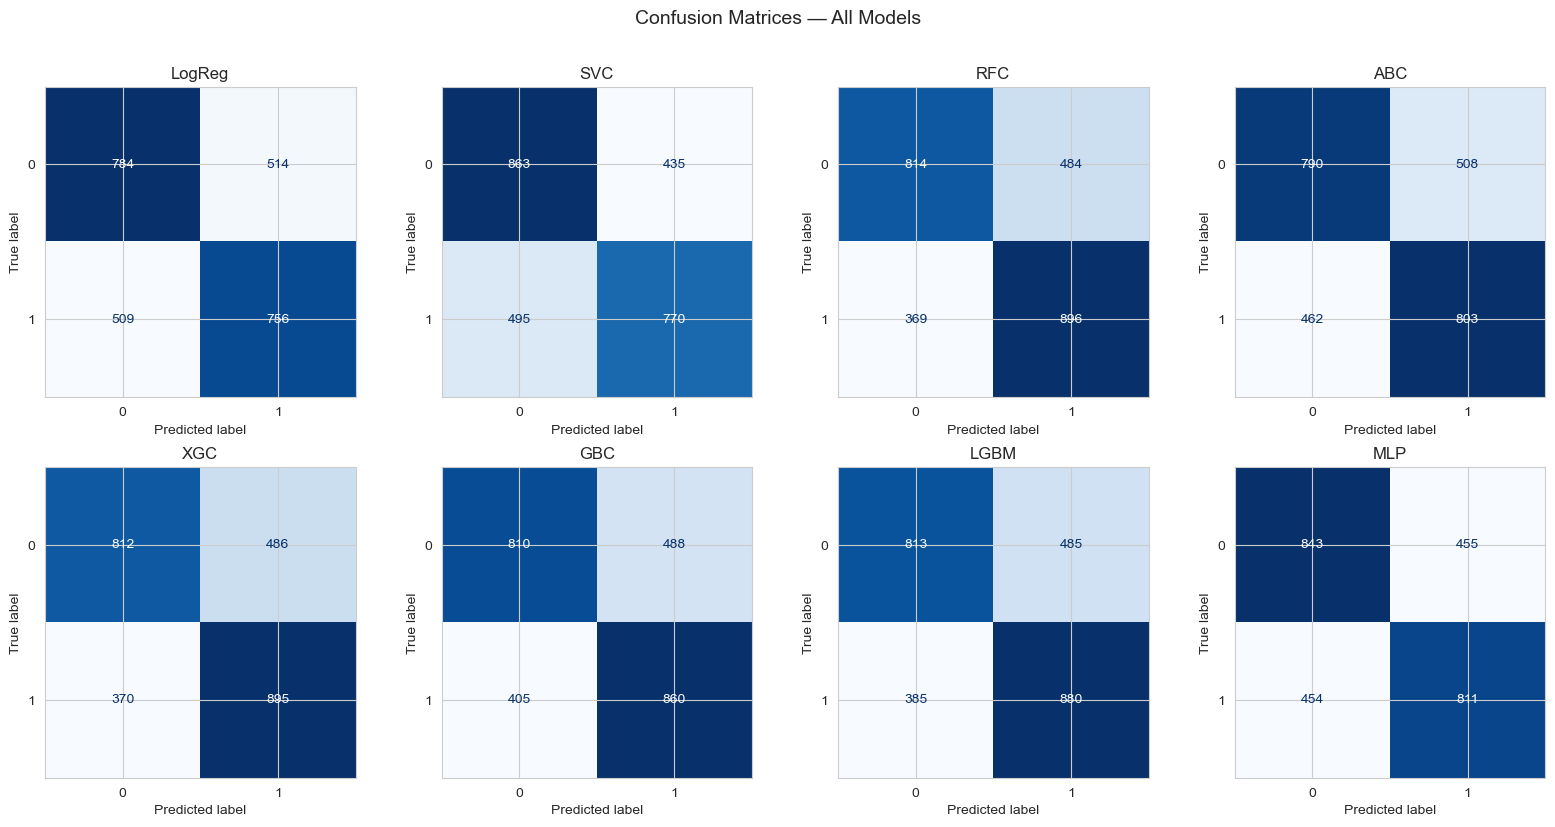

In [36]:
best_models        = {}
gridsearch_results = []

for name, model in model_definitions.items():
    print(f"{name} aranıyor...", end=" ", flush=True)

    gs = GridSearchCV(
        estimator  = model,
        param_grid = param_grids[name],
        cv         = 5, 
        scoring    = "f1_weighted",
        n_jobs     = -1,
        refit      = True
    )
    gs.fit(X_train, y_train)

    y_pred_tr = gs.predict(X_train)
    y_pred_te = gs.predict(X_test)
    best_models[name] = gs.best_estimator_

    gridsearch_results.append({
        "Model":             name,
        "Best Params":       gs.best_params_,
        "CV F1":             round(gs.best_score_, 4),
        "Train Accuracy":    round(accuracy_score(y_train, y_pred_tr), 4),
        "Test Accuracy":     round(accuracy_score(y_test,  y_pred_te), 4),
        "Precision":         round(precision_score(y_test, y_pred_te, average="weighted"), 4),
        "Recall":            round(recall_score(y_test,   y_pred_te, average="weighted"), 4),
        "F1 (weighted)":     round(f1_score(y_test,      y_pred_te, average="weighted"), 4),
        "Precision (macro)": round(precision_score(y_test, y_pred_te, average="macro"), 4),
        "Recall (macro)":    round(recall_score(y_test,   y_pred_te, average="macro"), 4),
        "F1 (macro)":        round(f1_score(y_test,      y_pred_te, average="macro"), 4),
        "Train-Test Gap":    round(accuracy_score(y_train, y_pred_tr) -
                                   accuracy_score(y_test,  y_pred_te), 4),
    })
    print(f"  CV F1={gs.best_score_:.4f}  |  {gs.best_params_}")

gs_df = pd.DataFrame(gridsearch_results).sort_values("F1 (weighted)", ascending=False)
print("\n===== GRIDSEARCH ÖZET =====")
print(gs_df[[
    "Model", "CV F1",
    "Train Accuracy", "Test Accuracy",
    "F1 (weighted)", "Precision", "Recall",
    "F1 (macro)", "Precision (macro)", "Recall (macro)",
    "Train-Test Gap"
]].to_string(index=False))

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    print("=" * 50)
    print(f"{name} — Classification Report")
    print("=" * 50)
    print(classification_report(y_test, y_pred, target_names=["Düşük", "Yüksek"]))

n_models = len(best_models)
n_cols   = 4
n_rows   = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.02)
plt.tight_layout(pad=1.0, h_pad=1.5, w_pad=1.0)
plt.show()

# 8. Model Karşılaştırması — İstatistiksel Test

**Yaklaşım:** Tek bir train/test bölünmesi istatistiksel güç açısından yetersizdir.  
30 farklı rastgele seed ile tekrarlı Holdout uygulanır; her seed'de tüm modeller yeniden eğitilip test doğruluğu kaydedilir.

- **Friedman Testi (global):** H0: Tüm modellerin doğruluk dağılımı aynıdır (k > 2 model için)
- **Wilcoxon Signed-Rank (ikili post-hoc):** Her çift için H0: İki modelin doğruluğu aynı dağılımdan gelir
- **Bonferroni düzeltmesi:** k model → k(k-1)/2 çift → α* = 0.05 / (k(k-1)/2)  
  *(k, best_models sözlüğündeki model sayısına göre çalışma zamanında hesaplanır)*

> **Not — Subject Leakage:** 30-seed Holdout, `train_test_split` ile yapıldığından aynı  
> katılımcının kayıtları hem eğitim hem test setinde yer alabilir. Bu, model doğruluklarını  
> hafifçe şişirir. Gerçek kişi-bağımsız değerlendirme için `GroupShuffleSplit(groups=SubjectID)`  
> kullanılması önerilir (bkz. Bölüm 10 sınırlılıklar).

=== 30 Seed Ortalama Test Doğrulukları ===
RFC       0.663571
XGC       0.658213
LGBM      0.658122
GBC       0.638132
MLP       0.636351
SVC       0.631422
ABC       0.615685
LogReg    0.599649


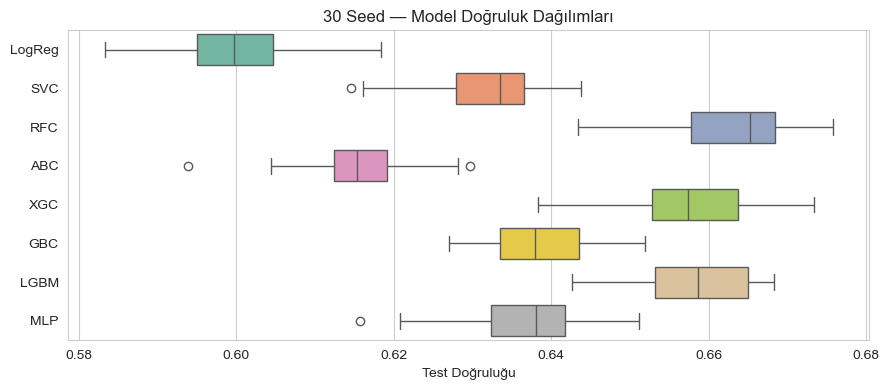

Friedman: istatistik=193.695, p=0.0000
→ H0 RED: Anlamlı fark var

Wilcoxon Post-Hoc (k=8 model → 28 çift → Bonferroni α*=0.0018)
Model 1 Model 2     W p-degeri Anlamli? (a*=0.0018)
 LogReg     SVC   0.0   0.0000                 Evet
 LogReg     RFC   0.0   0.0000                 Evet
 LogReg     ABC   1.0   0.0000                 Evet
 LogReg     XGC   0.0   0.0000                 Evet
 LogReg     GBC   0.0   0.0000                 Evet
 LogReg    LGBM   0.0   0.0000                 Evet
 LogReg     MLP   0.0   0.0000                 Evet
    SVC     RFC   0.0   0.0000                 Evet
    SVC     ABC   9.0   0.0000                 Evet
    SVC     XGC   0.0   0.0000                 Evet
    SVC     GBC  36.0   0.0001                 Evet
    SVC    LGBM   0.0   0.0000                 Evet
    SVC     MLP  67.0   0.0007                 Evet
    RFC     ABC   0.0   0.0000                 Evet
    RFC     XGC  81.5   0.0019                Hayir
    RFC     GBC   0.0   0.0000        

In [37]:
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations
from sklearn.base import clone

# 30 rastgele seed
rng = np.random.default_rng(0)
seeds = rng.choice(1000, size=30, replace=False)

model_names_list = list(best_models.keys())
acc_dict = {name: [] for name in model_names_list}

for seed in seeds:
    X_s_tr, X_s_te, y_s_tr, y_s_te = train_test_split(
        X, y, test_size=0.2, random_state=int(seed), stratify=y
    )
    sc = RobustScaler()
    X_s_tr = pd.DataFrame(sc.fit_transform(X_s_tr), columns=X_s_tr.columns, index=X_s_tr.index)
    X_s_te = pd.DataFrame(sc.transform(X_s_te),     columns=X_s_te.columns,  index=X_s_te.index)

    for name, model in best_models.items():
        m = clone(model)
        m.fit(X_s_tr, y_s_tr)
        acc_dict[name].append(m.score(X_s_te, y_s_te))

df_acc = pd.DataFrame(acc_dict)
print('=== 30 Seed Ortalama Test Doğrulukları ===')
print(df_acc.mean().sort_values(ascending=False).to_string())

plt.figure(figsize=(9, 4))
sns.boxplot(data=df_acc, orient='h', palette='Set2')
plt.xlabel('Test Doğruluğu')
plt.title('30 Seed — Model Doğruluk Dağılımları')
plt.tight_layout()
plt.show()

# Friedman Testi
acc_lists = [acc_dict[n] for n in model_names_list]
f_stat, f_p = friedmanchisquare(*acc_lists)
print(f'Friedman: istatistik={f_stat:.3f}, p={f_p:.4f}')
print('→ H0 RED: Anlamlı fark var' if f_p < 0.05 else '→ H0 KORUNDU: Anlamlı fark yok')

# Wilcoxon Post-Hoc — Bonferroni dinamik hesaplama
k = len(model_names_list)
n_pairs = k * (k - 1) // 2
alpha_bonf = 0.05 / n_pairs
print(f'\nWilcoxon Post-Hoc (k={k} model → {n_pairs} çift → Bonferroni α*={alpha_bonf:.4f})')

rows = []
for m1, m2 in combinations(model_names_list, 2):
    try:
        stat_w, p_w = wilcoxon(acc_dict[m1], acc_dict[m2])
    except ValueError:
        stat_w, p_w = float('nan'), float('nan')
    rows.append({
        'Model 1': m1,
        'Model 2': m2,
        'W': round(stat_w, 2) if stat_w == stat_w else 'NaN',
        'p-degeri': f'{p_w:.4f}' if p_w == p_w else 'NaN',
        f'Anlamli? (a*={alpha_bonf:.4f})': 'Evet' if (p_w == p_w and p_w < alpha_bonf) else 'Hayir'
    })

df_wilcoxon = pd.DataFrame(rows)
print(df_wilcoxon.to_string(index=False))

# 9. Final Model Değerlendirmesi

Tüm modeller aynı Holdout bölünmesinde (seed=42) karşılaştırılır.  
Her model için: Accuracy + Classification Report + Confusion Matrix.  
GridSearchCV CV F1 (weighted) skoruna göre **en iyi model** seçilip train/test confusion matrix'i yan yana gösterilir.

TUM MODELLERIN HOLDOUT PERFORMANSI (seed=42)
----------------------------------------
LogReg  |  Accuracy: 0.6009
              precision    recall  f1-score   support

   Düşük (0)       0.61      0.60      0.61      1298
  Yüksek (1)       0.60      0.60      0.60      1265

    accuracy                           0.60      2563
   macro avg       0.60      0.60      0.60      2563
weighted avg       0.60      0.60      0.60      2563



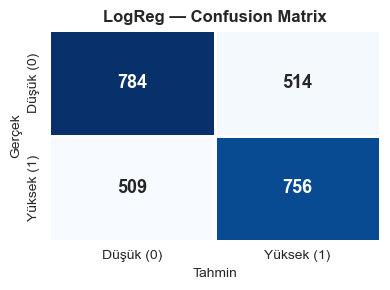

----------------------------------------
SVC  |  Accuracy: 0.6371
              precision    recall  f1-score   support

   Düşük (0)       0.64      0.66      0.65      1298
  Yüksek (1)       0.64      0.61      0.62      1265

    accuracy                           0.64      2563
   macro avg       0.64      0.64      0.64      2563
weighted avg       0.64      0.64      0.64      2563



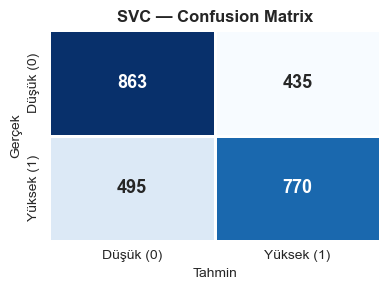

----------------------------------------
RFC  |  Accuracy: 0.6672
              precision    recall  f1-score   support

   Düşük (0)       0.69      0.63      0.66      1298
  Yüksek (1)       0.65      0.71      0.68      1265

    accuracy                           0.67      2563
   macro avg       0.67      0.67      0.67      2563
weighted avg       0.67      0.67      0.67      2563



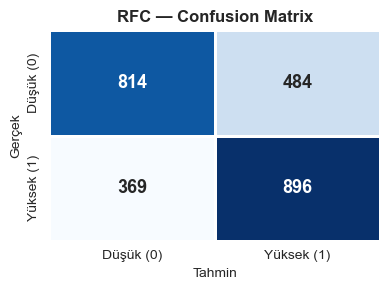

----------------------------------------
ABC  |  Accuracy: 0.6215
              precision    recall  f1-score   support

   Düşük (0)       0.63      0.61      0.62      1298
  Yüksek (1)       0.61      0.63      0.62      1265

    accuracy                           0.62      2563
   macro avg       0.62      0.62      0.62      2563
weighted avg       0.62      0.62      0.62      2563



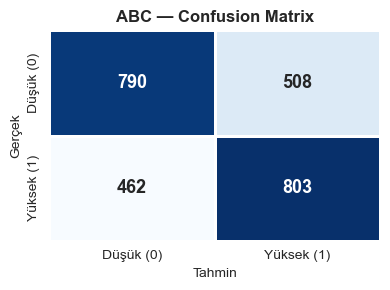

----------------------------------------
XGC  |  Accuracy: 0.6660
              precision    recall  f1-score   support

   Düşük (0)       0.69      0.63      0.65      1298
  Yüksek (1)       0.65      0.71      0.68      1265

    accuracy                           0.67      2563
   macro avg       0.67      0.67      0.67      2563
weighted avg       0.67      0.67      0.67      2563



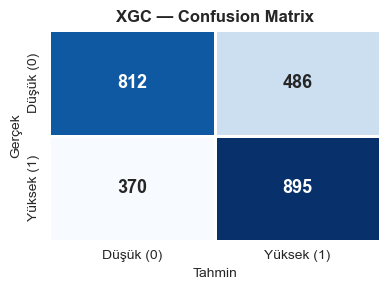

----------------------------------------
GBC  |  Accuracy: 0.6516
              precision    recall  f1-score   support

   Düşük (0)       0.67      0.62      0.64      1298
  Yüksek (1)       0.64      0.68      0.66      1265

    accuracy                           0.65      2563
   macro avg       0.65      0.65      0.65      2563
weighted avg       0.65      0.65      0.65      2563



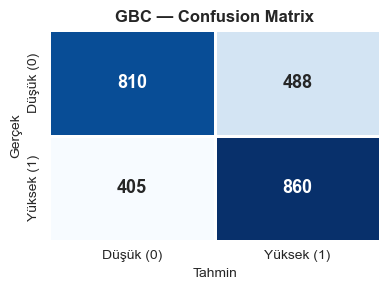

----------------------------------------
LGBM  |  Accuracy: 0.6606
              precision    recall  f1-score   support

   Düşük (0)       0.68      0.63      0.65      1298
  Yüksek (1)       0.64      0.70      0.67      1265

    accuracy                           0.66      2563
   macro avg       0.66      0.66      0.66      2563
weighted avg       0.66      0.66      0.66      2563



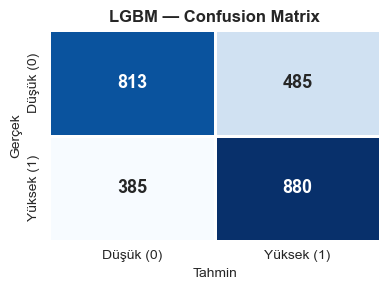

----------------------------------------
MLP  |  Accuracy: 0.6453
              precision    recall  f1-score   support

   Düşük (0)       0.65      0.65      0.65      1298
  Yüksek (1)       0.64      0.64      0.64      1265

    accuracy                           0.65      2563
   macro avg       0.65      0.65      0.65      2563
weighted avg       0.65      0.65      0.65      2563



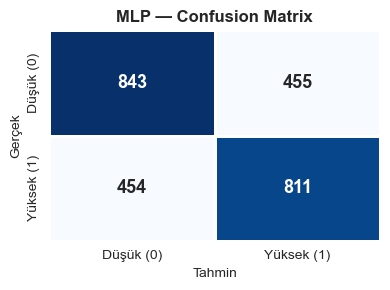

FINAL MODEL: GBC
Secim kriteri       : Gap <= 0.05 → en yuksek F1 (weighted)
Train-Test Gap      : 0.0460
CV F1 (GridSearch)  : 0.6318
Train Accuracy      : 0.6976
Test  Accuracy      : 0.6516
Test  F1 (weighted) : 0.6514
              precision    recall  f1-score   support

   Düşük (0)       0.67      0.62      0.64      1298
  Yüksek (1)       0.64      0.68      0.66      1265

    accuracy                           0.65      2563
   macro avg       0.65      0.65      0.65      2563
weighted avg       0.65      0.65      0.65      2563



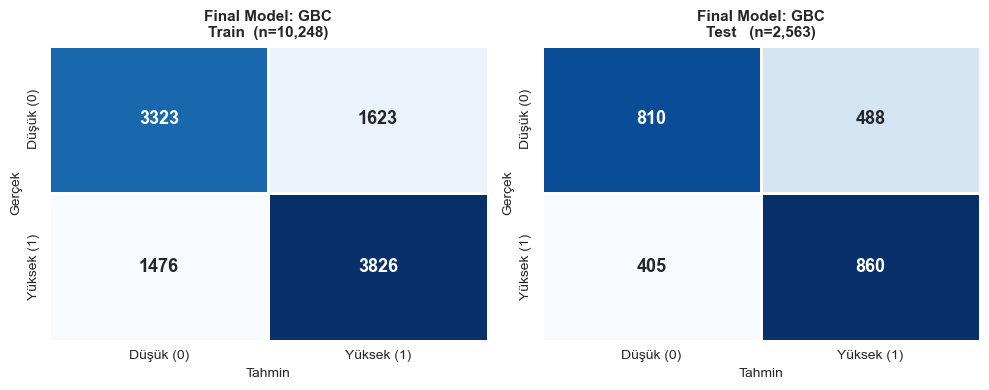

In [38]:
# Tum Modeller Karsilastirma Dongusu
print('=' * 60)
print('TUM MODELLERIN HOLDOUT PERFORMANSI (seed=42)')
print('=' * 60)

for name, model in best_models.items():
    y_pred_m = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_m)
    print(f'{"-"*40}')
    print(f'{name}  |  Accuracy: {acc:.4f}')
    print(classification_report(y_test, y_pred_m,
                                target_names=['Düşük (0)', 'Yüksek (1)']))
    cm = confusion_matrix(y_test, y_pred_m)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Düşük (0)', 'Yüksek (1)'],
                yticklabels=['Düşük (0)', 'Yüksek (1)'],
                linewidths=1, linecolor='white', cbar=False,
                annot_kws={'size': 13, 'fontweight': 'bold'})
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Final Model Secimi — Gap <= 0.05 gate + F1 (weighted) tiebreak
# Sadece yuksek F1 degil; overfitting riski olmayan adaylar arasinda sec.
GAP_THRESHOLD = 0.05
gs_df_sorted  = gs_df.sort_values('F1 (weighted)', ascending=False)
candidates    = gs_df_sorted[gs_df_sorted['Train-Test Gap'] <= GAP_THRESHOLD]

if len(candidates) == 0:
    best_row = gs_df_sorted.sort_values('Train-Test Gap').iloc[0]
    print(f'⚠️  Gap <= {GAP_THRESHOLD} esigini gecen model yok → en kucuk gap secildi.')
else:
    best_row = candidates.iloc[0]

best_name   = best_row['Model']
final_model = best_models[best_name]

y_pred_tr_final = final_model.predict(X_train)
y_pred_te_final = final_model.predict(X_test)

print(f'{"="*60}')
print(f'FINAL MODEL: {best_name}')
print(f'{"="*60}')
print(f'Secim kriteri       : Gap <= {GAP_THRESHOLD} → en yuksek F1 (weighted)')
print(f'Train-Test Gap      : {best_row["Train-Test Gap"]:.4f}')
print(f'CV F1 (GridSearch)  : {best_row["CV F1"]:.4f}')
print(f'Train Accuracy      : {accuracy_score(y_train, y_pred_tr_final):.4f}')
print(f'Test  Accuracy      : {accuracy_score(y_test,  y_pred_te_final):.4f}')
print(f'Test  F1 (weighted) : {f1_score(y_test, y_pred_te_final, average="weighted"):.4f}')
print(f'{classification_report(y_test, y_pred_te_final, target_names=["Düşük (0)", "Yüksek (1)"])}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_true, y_pred, title) in zip(axes, [
    (y_train, y_pred_tr_final, f'Train  (n={len(y_train):,})'),
    (y_test,  y_pred_te_final, f'Test   (n={len(y_test):,})')
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Düşük (0)', 'Yüksek (1)'],
                yticklabels=['Düşük (0)', 'Yüksek (1)'],
                linewidths=1, linecolor='white', cbar=False,
                annot_kws={'size': 13, 'fontweight': 'bold'})
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')
    ax.set_title(f'Final Model: {best_name}\n{title}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
